# SVM - Part 1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from cvxopt import matrix, solvers
import matplotlib.pyplot as plt
from SVM import *


In [2]:
df = pd.read_csv('dataset/GENDER_CLASSIFICATION.csv')
df.head()

,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,...,feat_24,feat_25,feat_26,feat_27,feat_28,feat_29,feat_30,feat_31,feat_32,gt
0,-0.900846,0.102587,-0.397814,0.112796,2.588096,-0.192754,-0.968311,-0.490886,-0.872099,-0.288411,...,2.541431,1.739102,0.166066,4.584869,-0.107031,-0.913990,-0.686416,-0.368085,-0.870545,0
1,-0.838868,0.039976,-0.387101,0.055413,2.066874,-0.226948,-0.947416,-0.472817,-0.855387,-0.207101,...,1.991721,1.259745,0.065058,3.019790,-0.110633,-0.890023,-0.611625,-0.298235,-0.855208,0
2,-0.814961,-0.010184,-0.397147,0.092713,1.897454,-0.269387,-0.945285,-0.449579,-0.849705,-0.151179,...,1.822978,1.105511,0.065353,2.500681,-0.052730,-0.885691,-0.583346,-0.218140,-0.856456,0
3,-0.110470,0.027849,-0.044310,-0.005343,0.177831,-0.232092,-0.562700,-0.400713,-0.552356,0.037349,...,-0.098367,-0.370318,-0.123008,-0.861314,0.106840,-0.483669,-0.224164,0.147321,-0.615051,0
4,-0.626313,-0.091985,-0.373756,-0.005083,1.172486,-0.314868,-0.885046,-0.412587,-0.818729,-0.012022,...,1.030348,0.421886,-0.068029,0.258984,-0.057158,-0.834079,-0.441066,-0.099874,-0.829539,0


General SVM class, contains the fit method using matrix and solvere (requested in part 1) and the svo and mvp method (requested in part 2)

In [ ]:
class SVM:
    def __init__(self, C=1.0, kernel='Gaussian', gamma=1, p=3,
                 tol=1e-6):
        # hyperparams
        self.C = float(C)
        self.kernel_type = kernel 
        self.gamma = gamma    
        self.p = p
        self.tol = tol

        # learned attributes
        self.alphas = None        # all alpha (length n)
        self.support_ = None      # indices of support vectors
        self.X_sv = None
        self.y_sv = None
        self.alpha_sv = None      # alphas corresponding to sv
        self.b = 0.0

        # preprocessing
        self.scaler = None
        # mapping labels -> {-1, +1}
        self.label_map = None
        self.inv_label_map = None



    def kernel(self, X1, X2=None):
            
            if X2 is None:
                X2 = X1

            if self.kernel_type == "Gaussian":
                # Compute squared norms
                X1_sq = np.sum(X1**2, axis=1).reshape(-1, 1)
                X2_sq = np.sum(X2**2, axis=1).reshape(1, -1)
                # Pairwise squared distance
                dist_sq = X1_sq + X2_sq - 2 * X1 @ X2.T
                # Gaussian kernel
                K = np.exp(-self.gamma * dist_sq)
                return K

            elif self.kernel_type == "Polynomial":
                K = (X1 @ X2.T + 1)**self.p
                return K
            

    def encode_labels(self, y):
        uniq = np.unique(y)
        if uniq.shape[0] != 2:
            raise ValueError("This implementation supports only binary classification.")
        # map unique[0] -> -1, unique[1] -> +1
        self.label_map = {uniq[0]: -1, uniq[1]: 1}
        self.inv_label_map = {-1: uniq[0], 1: uniq[1]}
        y_mapped = np.array([self.label_map[yy] for yy in y], dtype=float)
        return y_mapped
    
    
    def fit(self, X, y, verbose=False):
        """
        X: (n_samples, n_features) numpy array
        y: array-like labels (two classes)
        """

        if verbose:
            solvers.options['show_progress'] = True
        else:
            solvers.options['show_progress'] = False



        X = np.asarray(X, dtype=float)
        y_in = np.asarray(y).ravel()

        # encode labels to -1 / +1
        y = self.encode_labels(y_in)

        # scaling
        self.scaler = StandardScaler().fit(X)
        Xs = self.scaler.transform(X)

        n_samples = Xs.shape[0]

        # compute full kernel matrix
        K = self.kernel(Xs)    # (n_samples, n_samples)

        # Build Q = (y y^T) * K
        Y = y.reshape(-1, 1)
        Q = (Y @ Y.T) * K  # elementwise multiply
        # numerical stabilizer: symmetrize & add tiny jitter
        # Q = 0.5 * (Q + Q.T) + 1e-12 * np.eye(n_samples)

        P = matrix(Q)                         # cvxopt matrix
        q = matrix(-np.ones((n_samples, 1)))  # minimize 1/2 a^T P a + q^T a -> q = -1

        # G and h for 0 <= alpha <= C
        G_std = np.vstack((-np.eye(n_samples), np.eye(n_samples)))
        h_std = np.hstack((np.zeros(n_samples), np.ones(n_samples) * self.C))
        G = matrix(G_std)
        h = matrix(h_std)

        # equality A y = 0  (sum alpha_i y_i = 0)
        A = matrix(y.reshape(1, -1))
        b = matrix(0.0)

        sol = solvers.qp(P, q, G, h, A, b)

        # extract alphas (as numpy array)
        alphas_all = np.array(sol['x']).reshape(-1)

        # keep full alphas array for diagnostics
        self.alphas = alphas_all.copy()

        # support vectors: alpha > tol
        sv_mask = alphas_all > self.tol
        sv_indices = np.where(sv_mask)[0]
        self.support_ = sv_indices
        self.X_sv = Xs[sv_mask]
        self.y_sv = y[sv_mask]
        self.alpha_sv = alphas_all[sv_mask]

        # compute bias b: average over alphas with 0 < alpha < C (free SV)
        free_sv_mask = (alphas_all > self.tol) & (alphas_all < self.C - self.tol)
        free_indices = np.where(free_sv_mask)[0]

        if free_indices.size > 0:
            b_vals = []
            for i in free_indices:
                # f(x_i) = sum_j alpha_j y_j K(x_j, x_i)
                f_i = np.sum(alphas_all * y * K[:, i])
                b_vals.append(y[i] - f_i)
            self.b = np.mean(b_vals)
        else:
            # fallback: average over all support vectors
            b_vals = []
            for idx in sv_indices:
                f_i = np.sum(alphas_all * y * K[:, idx])
                b_vals.append(y[idx] - f_i)
            if len(b_vals) == 0:
                self.b = 0.0
            else:
                self.b = np.mean(b_vals)

        # keep training-data-size alphas if needed (self.alphas already)
        return self
    

    def decision_function(self, X):
        """Return raw decision scores (float), using only SV."""
        X = np.asarray(X, dtype=float)
        Xs = self.scaler.transform(X)
        K = self.kernel(Xs, self.X_sv)  # shape (m, n_sv)
        # weights = alpha_sv * y_sv (elementwise)
        weights = self.alpha_sv * self.y_sv
        scores = K @ weights + self.b    # shape (m,)
        return np.asarray(scores).reshape(-1)

    def predict(self, X):
        scores = self.decision_function(X)
        preds = np.where(scores >= 0, 1, -1)
        # map back to original labels
        return np.array([self.inv_label_map[int(p)] for p in preds])
    
    def score(self, X, y):
        y = np.asarray(y) 
        y_pred = self.predict(X)
        return np.mean(y_pred == y)
    

    def get_support(self):
        return self.support_
    
    def fit_smo(self, X, y, tol=1e-3, max_passes=10, max_iter=10):
        X = np.asarray(X, dtype=float)
        y_in = np.asarray(y).ravel()
        y_enc = self.encode_labels(y_in)
        self.scaler = StandardScaler().fit(X)
        Xs = self.scaler.transform(X)
        n = y_enc.shape[0]
        alphas = np.zeros(n)
        b = 0.0
        passes = 0
        iteration = 0
        K = self.kernel(Xs)

        def f(i):
            return np.sum(alphas * y_enc * K[:, i]) + b

        # Inizializza E in modo incrementale
        E = np.array([f(i) - y_enc[i] for i in range(n)])

        while passes < max_passes and iteration < max_iter:
            print(f"\n--- Iteration {iteration + 1}, consecutive passes without updates: {passes} ---")
            num_changed = 0
            tested_pairs = np.zeros((n, n), dtype=bool)  # Uso di una matrice booleana per il controllo

            for i in range(n):
                ei = E[i]
                ai = alphas[i]
                yi = y_enc[i]

                # Controllo KKT
                kkt_violation = ((ai < self.C and yi * ei < -tol) or (ai > 0 and yi * ei > tol))
                if not kkt_violation:
                    continue

                # Seleziona il secondo esempio in modo più efficiente
                candidates = np.where(np.abs(E - ei) > 1e-3)[0]  # Seleziona solo quelli con errore significativo
                candidates = candidates[candidates != i]  # Escludi il punto corrente

                if len(candidates) == 0:
                    continue

                j = np.argmax(np.abs(E[candidates] - ei))  # Seleziona il punto con l'errore maggiore

                # Se la coppia è già stata testata, salta
                if tested_pairs[i, j]:
                    continue
                tested_pairs[i, j] = True
                tested_pairs[j, i] = True  # Per evitare di testare di nuovo la stessa coppia (simmetria)

                aj = alphas[j]
                yj = y_enc[j]
                ej = E[j]

                # Calcola i limiti L e H
                if yi != yj:
                    L = max(0, aj - ai)
                    H = min(self.C, self.C + aj - ai)
                else:
                    L = max(0, ai + aj - self.C)
                    H = min(self.C, ai + aj)

                if L == H:
                    continue

                eta = 2 * K[i, j] - K[i, i] - K[j, j]
                if eta >= 0:
                    continue

                old_aj = aj
                alphas[j] -= yj * (ei - ej) / eta
                alphas[j] = np.clip(alphas[j], L, H)

                if abs(alphas[j] - old_aj) < 1e-5:
                    continue

                alphas[i] += yi * yj * (old_aj - alphas[j])

                # Aggiorna il bias b
                b1 = b - ei - yi * (alphas[i] - ai) * K[i, i] - yj * (alphas[j] - old_aj) * K[i, j]
                b2 = b - ej - yi * (alphas[i] - ai) * K[i, j] - yj * (alphas[j] - old_aj) * K[j, j]

                if 0 < alphas[i] < self.C:
                    b = b1
                elif 0 < alphas[j] < self.C:
                    b = b2
                else:
                    b = (b1 + b2) / 2

                # Aggiorna l'errore
                E = np.array([f(k) - y_enc[k] for k in range(n)])
                num_changed += 1

            
            print(f"Number of alphas updated in this iteration: {num_changed}")

            if num_changed == 0:
                passes += 1
            else:
                passes = 0

            iteration += 1

        # Salva il modello finale
        sv_mask = alphas > 1e-6
        self.alpha_sv = alphas[sv_mask]
        self.b = b
        self.X_sv = Xs[sv_mask]
        self.y_sv = y_enc[sv_mask]

        print(f"\nTraining completed in {iteration} iterations. Total support vectors: {len(self.alpha_sv)}")
        return self

In [3]:
# Example usage classic fit:
# Split features and target
X = df.drop("gt", axis=1).values
y = df["gt"].values

# Train/val split (80/20)
split = int(0.8 * len(X))
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = SVM(C=1.0, kernel='Gaussian', gamma=0.5)

model.fit(X_train, y_train, verbose=True)

# ----- 4. Evaluation -----
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Accuracy on training set:", train_acc)
print("Accuracy on test set:", test_acc)

     pcost       dcost       gap    pres   dres
 0: -1.7863e+02 -1.7813e+03  9e+03  3e+00  1e-15
 1: -1.0780e+02 -1.0270e+03  1e+03  1e-01  1e-15
 2: -1.2223e+02 -2.6517e+02  2e+02  1e-02  1e-15
 3: -1.3459e+02 -1.7026e+02  4e+01  2e-03  8e-16
 4: -1.3798e+02 -1.4939e+02  1e+01  4e-04  7e-16
 5: -1.3960e+02 -1.4311e+02  4e+00  2e-15  8e-16
 6: -1.4018e+02 -1.4136e+02  1e+00  3e-15  9e-16
 7: -1.4041e+02 -1.4084e+02  4e-01  4e-15  8e-16
 8: -1.4053e+02 -1.4059e+02  6e-02  1e-15  8e-16
 9: -1.4055e+02 -1.4056e+02  6e-03  7e-15  8e-16
10: -1.4055e+02 -1.4055e+02  2e-04  5e-15  9e-16
11: -1.4055e+02 -1.4055e+02  3e-06  3e-15  9e-16
Optimal solution found.
Accuracy on training set: 0.92
Accuracy on test set: 0.91


In [6]:
def grid_search_cv(X, y, C_grid, gamma_grid=None, degree_grid=None,
                   k=5, random_state=0, smo=False):
    """
    Grid search for Gaussian and Polynomial SVM with k-fold CV.
    Returns: best_params, best_score, all_results (list of dicts)
    """
    from sklearn.model_selection import StratifiedKFold
    import numpy as np

    y = np.asarray(y).ravel()
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)

    best_score = -np.inf
    best_params = {}
    all_results = []


    if not smo:
        for C in C_grid:
            # --- Gaussian kernel ---
            if gamma_grid:
                for gamma in gamma_grid:
                    scores = []
                    for train_idx, val_idx in skf.split(X, y):
                        model = SVM(C=C, kernel='Gaussian', gamma=gamma)
                        model.fit(X[train_idx], y[train_idx])
                        scores.append(model.score(X[val_idx], y[val_idx]))
                    mean_score = np.mean(scores)
                    all_results.append({
                        'kernel': 'Gaussian', 'C': C, 'gamma': gamma,
                        'mean_score': mean_score
                    })
                    if mean_score > best_score:
                        best_score = mean_score
                        best_params = {'C': C, 'gamma': gamma, 'kernel': 'Gaussian'}

            # --- Polynomial kernel ---
            if degree_grid:
                for degree in degree_grid:
                    scores = []
                    for train_idx, val_idx in skf.split(X, y):
                        model = SVM(C=C, kernel='Polynomial', p=degree)
                        model.fit(X[train_idx], y[train_idx])
                        scores.append(model.score(X[val_idx], y[val_idx]))
                    mean_score = np.mean(scores)
                    all_results.append({
                        'kernel': 'Polynomial', 'C': C, 'degree': degree,
                        'mean_score': mean_score
                    })
                    if mean_score > best_score:
                        best_score = mean_score
                        best_params = {'C': C, 'degree': degree, 'kernel': 'Polynomial'}
    else:
        for C in C_grid:
            # --- Gaussian kernel ---
            if gamma_grid:
                for gamma in gamma_grid:
                    scores = []
                    for train_idx, val_idx in skf.split(X, y):
                        model = SVM(C=C, kernel='Gaussian', gamma=gamma)
                        model.fit_smo(X[train_idx], y[train_idx])
                        scores.append(model.score(X[val_idx], y[val_idx]))
                    mean_score = np.mean(scores)
                    all_results.append({
                        'kernel': 'Gaussian', 'C': C, 'gamma': gamma,
                        'mean_score': mean_score})
                    print(f"Trying C={C}, gamma={gamma} -> mean score={mean_score:.4f}")
                    if mean_score > best_score:
                        best_score = mean_score
                        best_params = {'C': C, 'gamma': gamma, 'kernel': 'Gaussian'}

            # --- Polynomial kernel ---
            if degree_grid:
                for degree in degree_grid:
                    scores = []
                    for train_idx, val_idx in skf.split(X, y):
                        model = SVM(C=C, kernel='Polynomial', p=degree)
                        model.fit_smo(X[train_idx], y[train_idx])
                        scores.append(model.score(X[val_idx], y[val_idx]))
                    mean_score = np.mean(scores)
                    all_results.append({
                        'kernel': 'Polynomial', 'C': C, 'degree': degree,
                        'mean_score': mean_score})
                    print(f"Trying C={C}, degree={degree} -> mean score={mean_score:.4f}")

                    if mean_score > best_score:
                        best_score = mean_score
                        best_params = {'C': C, 'degree': degree, 'kernel': 'Polynomial'}

    print(best_params, best_score)
    return best_params, best_score, all_results


In [ ]:
# Split features and target
X = df.drop("gt", axis=1).values
y = df["gt"].values.reshape(-1, 1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2) grid search 
C_grid = [0.01, 0.1, 1, 10]
gamma_grid = [0.001, 0.01, 0.1, 1]
degree_grid = [1, 2, 3, 4]

best_params, best_score, all_results = grid_search_cv(
    X_train, y_train,
    C_grid, gamma_grid=gamma_grid, degree_grid=degree_grid, k=5
)


print("Best:", best_params, "score:", best_score)

# 3) final fit with best hyperparams
if best_params['kernel'] == 'Polynomial':
    model = SVM(C=best_params['C'], kernel='Polynomial', p=best_params['degree'])
else:
    model = SVM(C=best_params['C'], kernel=best_params['kernel'], gamma=best_params['gamma'])

model.fit(X_train, y_train)

# 4) test 
y_pred = model.predict(X_test)
X_pred = model.predict(X_train)





{'C': 0.1, 'degree': 3, 'kernel': 'Polynomial'} 0.9237499999999998
Best: {'C': 0.1, 'degree': 3, 'kernel': 'Polynomial'} score: 0.9237499999999998


In [8]:
print(classification_report(y_train, X_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       404
           1       0.94      0.95      0.95       396

    accuracy                           0.95       800
   macro avg       0.95      0.95      0.95       800
weighted avg       0.95      0.95      0.95       800



In [9]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.89      0.92      0.90        96
           1       0.92      0.89      0.91       104

    accuracy                           0.91       200
   macro avg       0.90      0.91      0.90       200
weighted avg       0.91      0.91      0.91       200



C:\Users\User\AppData\Local\Temp\ipykernel_18408\3647372425.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_scores, x="kernel", y="mean_score", palette="Set2")


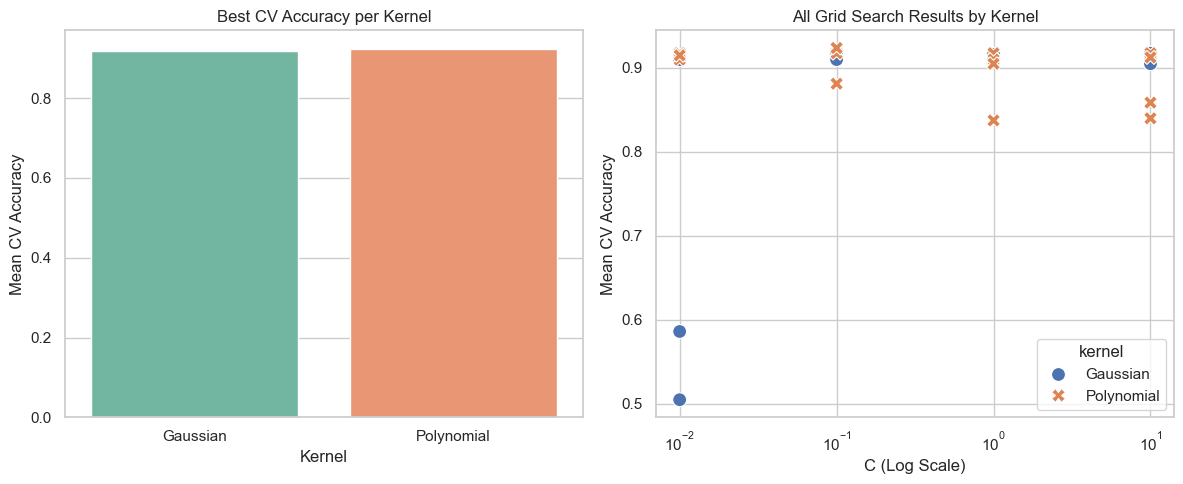

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results_df = pd.DataFrame(all_results)

sns.set(style="whitegrid")
plt.figure(figsize=(12, 5))

# 1. General comparson of best scores per kernel
plt.subplot(1, 2, 1)
best_scores = results_df.groupby("kernel")["mean_score"].max().reset_index()
sns.barplot(data=best_scores, x="kernel", y="mean_score", palette="Set2")
plt.title("Best CV Accuracy per Kernel")
plt.ylabel("Mean CV Accuracy")
plt.xlabel("Kernel")

# 2. Line plot for all results 
plt.subplot(1, 2, 2)
sns.scatterplot(data=results_df, x="C", y="mean_score", hue="kernel", style="kernel", s=100)
plt.title("All Grid Search Results by Kernel")
plt.ylabel("Mean CV Accuracy")
plt.xlabel("C (Log Scale)")
plt.xscale("log")

plt.tight_layout()
plt.show()


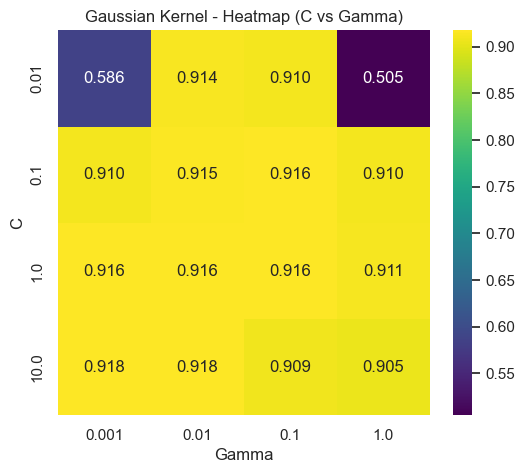

In [11]:
gaussian_df = results_df[results_df['kernel'] == 'Gaussian']
if not gaussian_df.empty:
    pivot_table = gaussian_df.pivot(index='C', columns='gamma', values='mean_score')
    plt.figure(figsize=(6, 5))
    sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
    plt.title("Gaussian Kernel - Heatmap (C vs Gamma)")
    plt.xlabel("Gamma")
    plt.ylabel("C")
    plt.show()


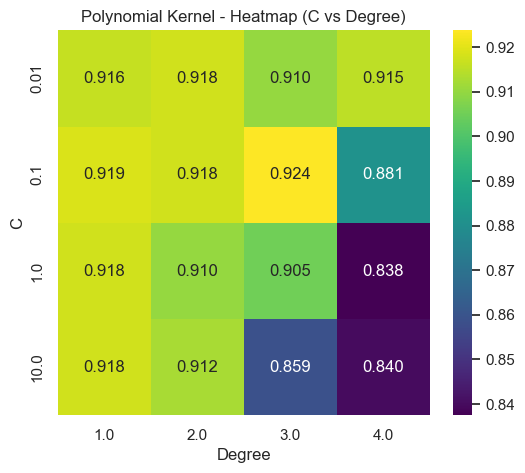

In [12]:
poly_df = results_df[results_df['kernel'] == 'Polynomial']
if not poly_df.empty:
    pivot_table = poly_df.pivot(index='C', columns='degree', values='mean_score')
    plt.figure(figsize=(6, 5))
    sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
    plt.title("Polynomial Kernel - Heatmap (C vs Degree)")
    plt.xlabel("Degree")
    plt.ylabel("C")
    plt.show()

In [13]:
poly_df['C'] = poly_df['C'].astype(str)
gaussian_df['C'] = gaussian_df['C'].astype(str)

C:\Users\User\AppData\Local\Temp\ipykernel_18408\3821612633.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  poly_df['C'] = poly_df['C'].astype(str)
C:\Users\User\AppData\Local\Temp\ipykernel_18408\3821612633.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gaussian_df['C'] = gaussian_df['C'].astype(str)


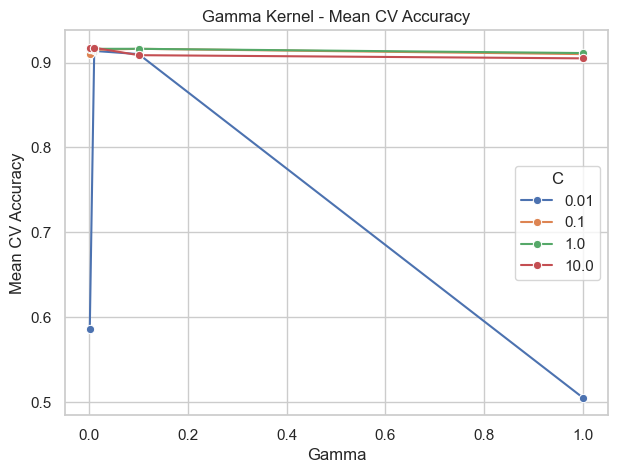

In [14]:
if not gaussian_df.empty:
    plt.figure(figsize=(7, 5))
    sns.lineplot(data=gaussian_df, x='gamma', y='mean_score', hue='C', marker='o')
    plt.title("Gamma Kernel - Mean CV Accuracy")
    plt.xlabel("Gamma")
    plt.ylabel("Mean CV Accuracy")
    plt.legend(title="C")
    plt.show()

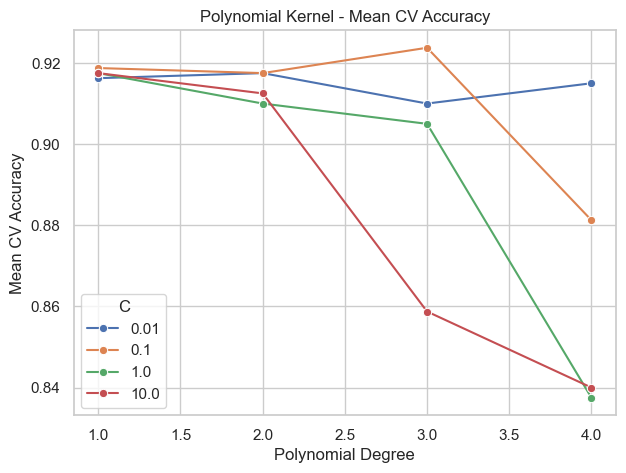

In [15]:
if not poly_df.empty:
    plt.figure(figsize=(7, 5))
    sns.lineplot(data=poly_df, x='degree', y='mean_score', hue='C', marker='o')
    plt.title("Polynomial Kernel - Mean CV Accuracy")
    plt.xlabel("Polynomial Degree")
    plt.ylabel("Mean CV Accuracy")
    plt.legend(title="C")
    plt.show()


New grid_search that is more precise on the parameters that resulted to be better for the SVM

In [ ]:
# Split features and target
X = df.drop("gt", axis=1).values
y = df["gt"].values.reshape(-1, 1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2) grid search 
C = [0.05, 0.1, 0.2, 0.5, 1, 2, 5]
gamma_grid = [0.005, 0.01, 0.02, 0.05, 0.1]
degree_grid = [2, 3, 5, 10]

best_params, best_score, all_results = grid_search_cv(
    X_train, y_train,
    C_grid=C,  
    gamma_grid=gamma_grid,
    degree_grid=degree_grid,
    k=5
)


print("Best:", best_params, "score:", best_score)

# 3) final fit with best hyperparams
if best_params['kernel'] == 'Polynomial':
    model = SVM(C=best_params['C'], kernel='Polynomial', p=best_params['degree'])
else:
    model = SVM(C=best_params['C'], kernel=best_params['kernel'], gamma=best_params['gamma'])

model.fit(X_train, y_train)

# 4) test 
y_pred = model.predict(X_test)
X_pred = model.predict(X_train)





{'C': 0.1, 'degree': 3, 'kernel': 'Polynomial'} 0.9237499999999998
Best: {'C': 0.1, 'degree': 3, 'kernel': 'Polynomial'} score: 0.9237499999999998


In [17]:
print(classification_report(y_train, X_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       404
           1       0.94      0.95      0.95       396

    accuracy                           0.95       800
   macro avg       0.95      0.95      0.95       800
weighted avg       0.95      0.95      0.95       800



In [18]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.89      0.92      0.90        96
           1       0.92      0.89      0.91       104

    accuracy                           0.91       200
   macro avg       0.90      0.91      0.90       200
weighted avg       0.91      0.91      0.91       200



C:\Users\User\AppData\Local\Temp\ipykernel_18408\1660918594.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_scores, x="kernel", y="mean_score", palette="Set2")


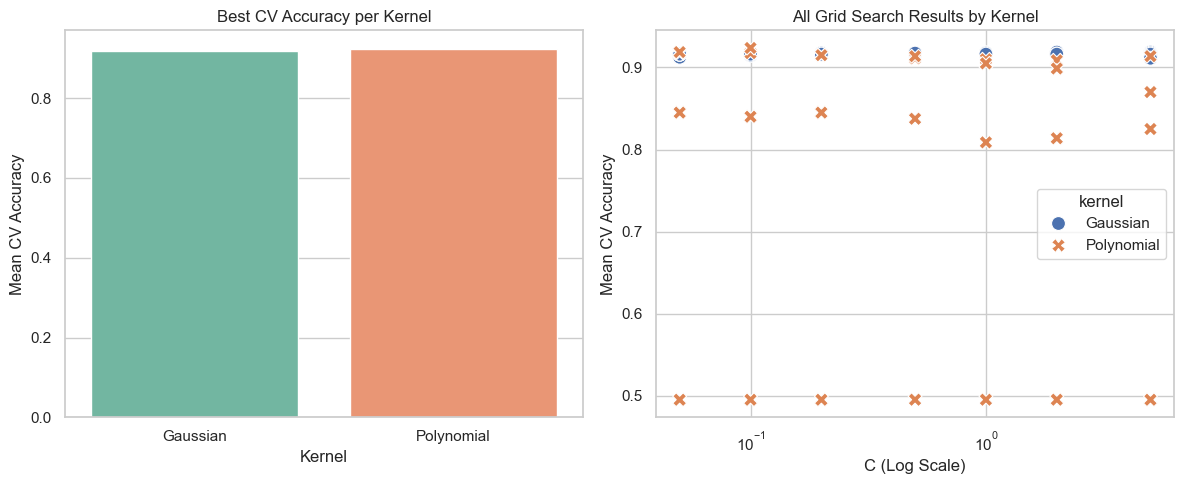

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results_df = pd.DataFrame(all_results)

sns.set(style="whitegrid")
plt.figure(figsize=(12, 5))

# 1. General comparson of best scores per kernel
plt.subplot(1, 2, 1)
best_scores = results_df.groupby("kernel")["mean_score"].max().reset_index()
sns.barplot(data=best_scores, x="kernel", y="mean_score", palette="Set2")
plt.title("Best CV Accuracy per Kernel")
plt.ylabel("Mean CV Accuracy")
plt.xlabel("Kernel")

# 2. Line plot for all results 
plt.subplot(1, 2, 2)
sns.scatterplot(data=results_df, x="C", y="mean_score", hue="kernel", style="kernel", s=100)
plt.title("All Grid Search Results by Kernel")
plt.ylabel("Mean CV Accuracy")
plt.xlabel("C (Log Scale)")
plt.xscale("log")

plt.tight_layout()
plt.show()


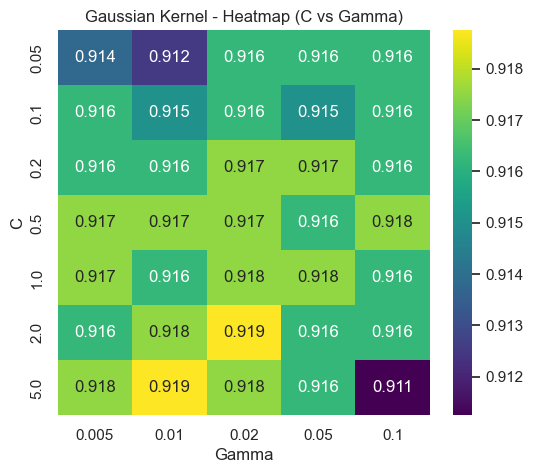

In [21]:
gaussian_df = results_df[results_df['kernel'] == 'Gaussian']
if not gaussian_df.empty:
    pivot_table = gaussian_df.pivot(index='C', columns='gamma', values='mean_score')
    plt.figure(figsize=(6, 5))
    sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
    plt.title("Gaussian Kernel - Heatmap (C vs Gamma)")
    plt.xlabel("Gamma")
    plt.ylabel("C")
    plt.show()


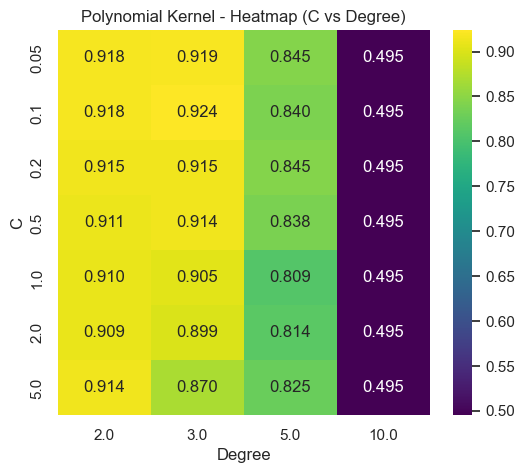

In [20]:
poly_df = results_df[results_df['kernel'] == 'Polynomial']
if not poly_df.empty:
    pivot_table = poly_df.pivot(index='C', columns='degree', values='mean_score')
    plt.figure(figsize=(6, 5))
    sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
    plt.title("Polynomial Kernel - Heatmap (C vs Degree)")
    plt.xlabel("Degree")
    plt.ylabel("C")
    plt.show()

In [22]:
poly_df['C'] = poly_df['C'].astype(str)
gaussian_df['C'] = gaussian_df['C'].astype(str)

C:\Users\User\AppData\Local\Temp\ipykernel_18408\3821612633.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  poly_df['C'] = poly_df['C'].astype(str)
C:\Users\User\AppData\Local\Temp\ipykernel_18408\3821612633.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gaussian_df['C'] = gaussian_df['C'].astype(str)


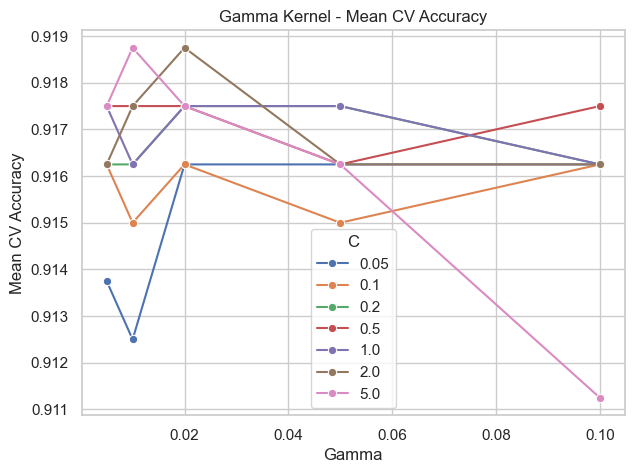

In [23]:
if not gaussian_df.empty:
    plt.figure(figsize=(7, 5))
    sns.lineplot(data=gaussian_df, x='gamma', y='mean_score', hue='C', marker='o')
    plt.title("Gamma Kernel - Mean CV Accuracy")
    plt.xlabel("Gamma")
    plt.ylabel("Mean CV Accuracy")
    plt.legend(title="C")
    plt.show()

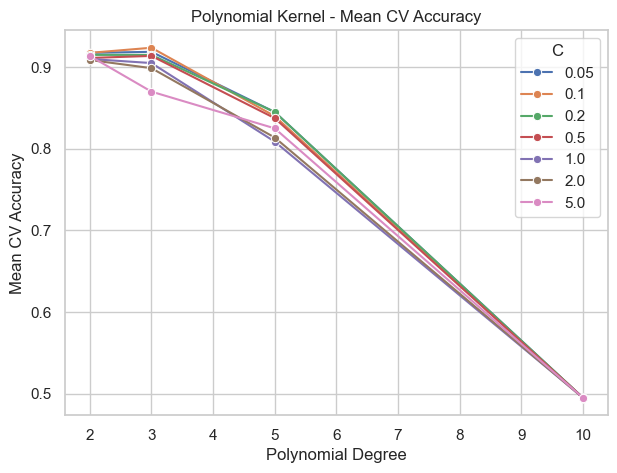

In [24]:
if not poly_df.empty:
    plt.figure(figsize=(7, 5))
    sns.lineplot(data=poly_df, x='degree', y='mean_score', hue='C', marker='o')
    plt.title("Polynomial Kernel - Mean CV Accuracy")
    plt.xlabel("Polynomial Degree")
    plt.ylabel("Mean CV Accuracy")
    plt.legend(title="C")
    plt.show()


# Part 2

In [ ]:
# Example usage smo fit:
# Split features and target
X = df.drop("gt", axis=1).values
y = df["gt"].values

# Train/val split (80/20)
split = int(0.8 * len(X))
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = SVM(C=1.0, kernel='Gaussian', gamma=0.5)

model.fit_smo(X_train, y_train)

# ----- 4. Evaluation -----
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Accuracy on training set:", train_acc)
print("Accuracy on test set:", test_acc)


--- Iteration 1, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 89

--- Iteration 2, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 78

--- Iteration 3, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 74

--- Iteration 4, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 30

--- Iteration 5, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 53

--- Iteration 6, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 67

--- Iteration 7, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 50

--- Iteration 8, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 23

--- Iteration 9, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 33

--- Iteration 10, consecutive passes

In [ ]:
# Split features and target
X = df.drop("gt", axis=1).values
y = df["gt"].values.reshape(-1, 1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2) grid search 
C_grid = [0.01, 0.1, 1, 10]
gamma_grid = [0.001, 0.01, 0.1, 1]
degree_grid = [1 ,2, 3, 4]

best_params, best_score, all_results = grid_search_cv(
    X_train, y_train,
    C_grid, gamma_grid=gamma_grid, degree_grid=degree_grid, k=5, smo=True
)


print("Best:", best_params, "score:", best_score)

# 3) final fit with best hyperparams
if best_params['kernel'] == 'Polynomial':
    model = SVM(C=best_params['C'], kernel='Polynomial', p=best_params['degree'])
else:
    model = SVM(C=best_params['C'], kernel=best_params['kernel'], gamma=best_params['gamma'])

model.fit_smo(X_train, y_train)

# 4) test 
y_pred = model.predict(X_test)
X_pred = model.predict(X_train)


--- Iteration 1, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 36

--- Iteration 2, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 0

--- Iteration 3, consecutive passes without updates: 1 ---
Number of alphas updated in this iteration: 0

--- Iteration 4, consecutive passes without updates: 2 ---
Number of alphas updated in this iteration: 0

--- Iteration 5, consecutive passes without updates: 3 ---
Number of alphas updated in this iteration: 0

--- Iteration 6, consecutive passes without updates: 4 ---
Number of alphas updated in this iteration: 0

--- Iteration 7, consecutive passes without updates: 5 ---
Number of alphas updated in this iteration: 0

--- Iteration 8, consecutive passes without updates: 6 ---
Number of alphas updated in this iteration: 0

--- Iteration 9, consecutive passes without updates: 7 ---
Number of alphas updated in this iteration: 0

--- Iteration 10, consecutive passes without

C:\Users\User\AppData\Local\Temp\ipykernel_17972\1660918594.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_scores, x="kernel", y="mean_score", palette="Set2")


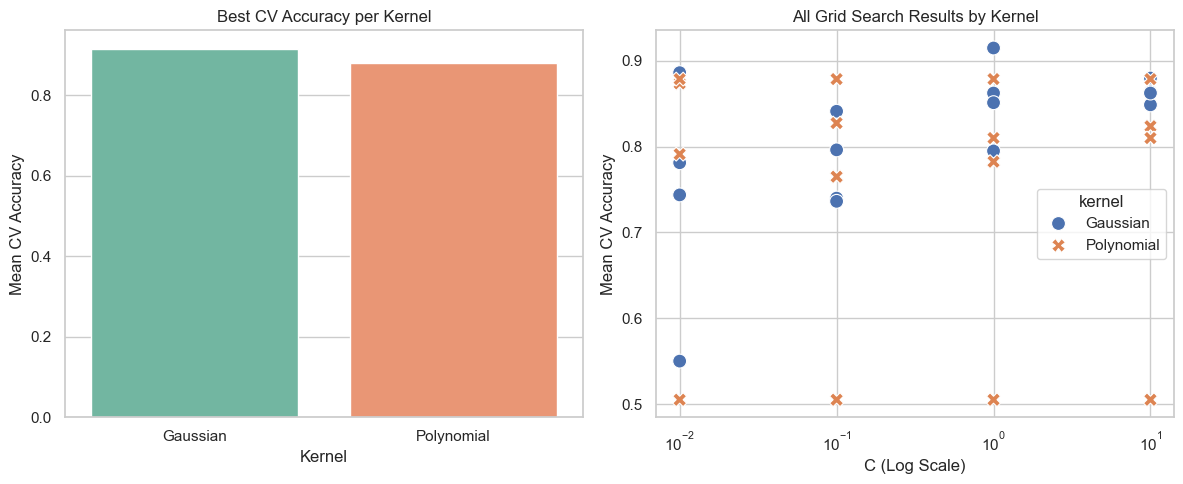

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results_df = pd.DataFrame(all_results)

sns.set(style="whitegrid")
plt.figure(figsize=(12, 5))

# 1. General comparson of best scores per kernel
plt.subplot(1, 2, 1)
best_scores = results_df.groupby("kernel")["mean_score"].max().reset_index()
sns.barplot(data=best_scores, x="kernel", y="mean_score", palette="Set2")
plt.title("Best CV Accuracy per Kernel")
plt.ylabel("Mean CV Accuracy")
plt.xlabel("Kernel")

# 2. Line plot for all results 
plt.subplot(1, 2, 2)
sns.scatterplot(data=results_df, x="C", y="mean_score", hue="kernel", style="kernel", s=100)
plt.title("All Grid Search Results by Kernel")
plt.ylabel("Mean CV Accuracy")
plt.xlabel("C (Log Scale)")
plt.xscale("log")

plt.tight_layout()
plt.show()


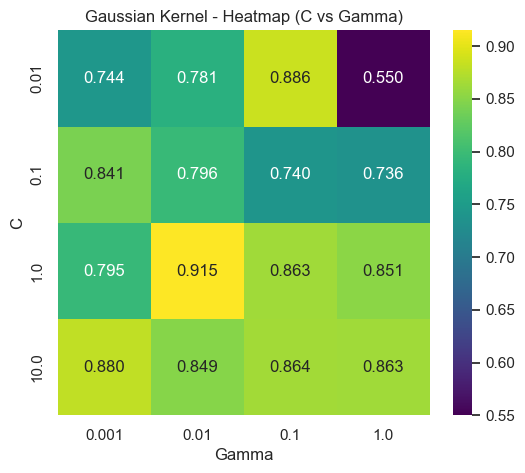

In [59]:
gaussian_df = results_df[results_df['kernel'] == 'Gaussian']
if not gaussian_df.empty:
    pivot_table = gaussian_df.pivot(index='C', columns='gamma', values='mean_score')
    plt.figure(figsize=(6, 5))
    sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
    plt.title("Gaussian Kernel - Heatmap (C vs Gamma)")
    plt.xlabel("Gamma")
    plt.ylabel("C")
    plt.show()


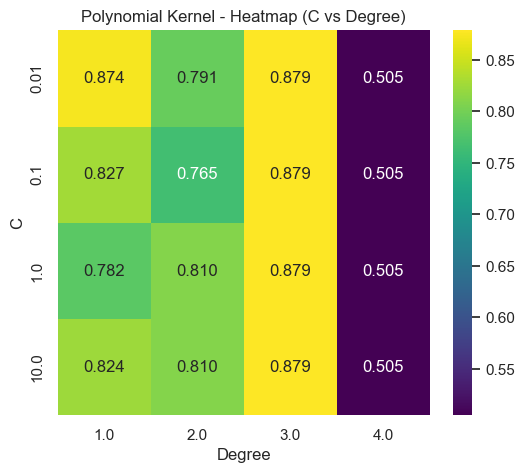

In [60]:
poly_df = results_df[results_df['kernel'] == 'Polynomial']
if not poly_df.empty:
    pivot_table = poly_df.pivot(index='C', columns='degree', values='mean_score')
    plt.figure(figsize=(6, 5))
    sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
    plt.title("Polynomial Kernel - Heatmap (C vs Degree)")
    plt.xlabel("Degree")
    plt.ylabel("C")
    plt.show()

In [61]:
poly_df['C'] = poly_df['C'].astype(str)
gaussian_df['C'] = gaussian_df['C'].astype(str)

C:\Users\User\AppData\Local\Temp\ipykernel_17972\3821612633.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  poly_df['C'] = poly_df['C'].astype(str)
C:\Users\User\AppData\Local\Temp\ipykernel_17972\3821612633.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gaussian_df['C'] = gaussian_df['C'].astype(str)


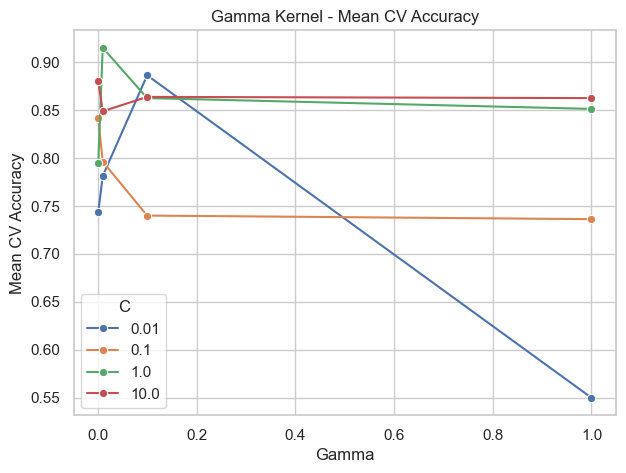

In [62]:
if not gaussian_df.empty:
    plt.figure(figsize=(7, 5))
    sns.lineplot(data=gaussian_df, x='gamma', y='mean_score', hue='C', marker='o')
    plt.title("Gamma Kernel - Mean CV Accuracy")
    plt.xlabel("Gamma")
    plt.ylabel("Mean CV Accuracy")
    plt.legend(title="C")
    plt.show()

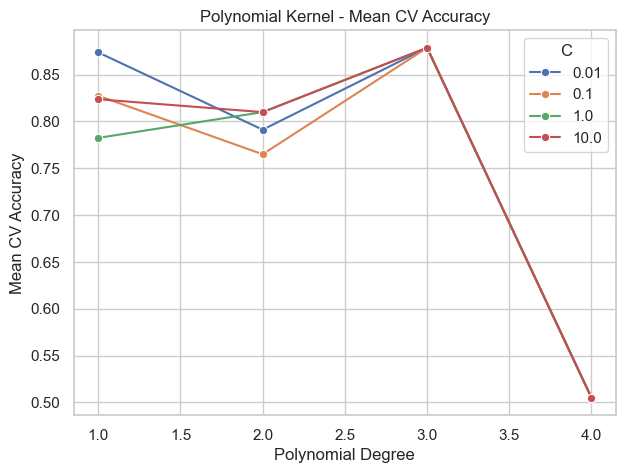

In [63]:
if not poly_df.empty:
    plt.figure(figsize=(7, 5))
    sns.lineplot(data=poly_df, x='degree', y='mean_score', hue='C', marker='o')
    plt.title("Polynomial Kernel - Mean CV Accuracy")
    plt.xlabel("Polynomial Degree")
    plt.ylabel("Mean CV Accuracy")
    plt.legend(title="C")
    plt.show()


New grid search as in part 1

In [ ]:
# Split features and target
X = df.drop("gt", axis=1).values
y = df["gt"].values.reshape(-1, 1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2) grid search 
C = [0.05, 0.1, 0.2, 0.5, 1, 2, 5]
gamma_grid = [0.005, 0.01, 0.02, 0.05, 0.1]
degree_grid = [2, 3, 5, 10]

best_params, best_score, all_results = grid_search_cv(
    X_train, y_train,
    C_grid=C,  
    gamma_grid=gamma_grid,
    degree_grid=degree_grid,
    k=5,
    smo=True
)


print("Best:", best_params, "score:", best_score)

# 3) final fit with best hyperparams
if best_params['kernel'] == 'Polynomial':
    model = SVM(C=best_params['C'], kernel='Polynomial', p=best_params['degree'])
else:
    model = SVM(C=best_params['C'], kernel=best_params['kernel'], gamma=best_params['gamma'])

model.fit_smo(X_train, y_train)

# 4) test 
y_pred = model.predict(X_test)
X_pred = model.predict(X_train)






--- Iteration 1, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 16

--- Iteration 2, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 0

--- Iteration 3, consecutive passes without updates: 1 ---
Number of alphas updated in this iteration: 0

--- Iteration 4, consecutive passes without updates: 2 ---
Number of alphas updated in this iteration: 0

--- Iteration 5, consecutive passes without updates: 3 ---
Number of alphas updated in this iteration: 0

--- Iteration 6, consecutive passes without updates: 4 ---
Number of alphas updated in this iteration: 0

--- Iteration 7, consecutive passes without updates: 5 ---
Number of alphas updated in this iteration: 0

--- Iteration 8, consecutive passes without updates: 6 ---
Number of alphas updated in this iteration: 0

--- Iteration 9, consecutive passes without updates: 7 ---
Number of alphas updated in this iteration: 0

--- Iteration 10, consecutive passes without

In [88]:
print(classification_report(y_train, X_pred))

              precision    recall  f1-score   support

           0       0.97      0.78      0.86       404
           1       0.81      0.97      0.88       396

    accuracy                           0.87       800
   macro avg       0.89      0.87      0.87       800
weighted avg       0.89      0.87      0.87       800



In [89]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.96      0.82      0.89        96
           1       0.86      0.97      0.91       104

    accuracy                           0.90       200
   macro avg       0.91      0.90      0.90       200
weighted avg       0.91      0.90      0.90       200



C:\Users\User\AppData\Local\Temp\ipykernel_17972\1660918594.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_scores, x="kernel", y="mean_score", palette="Set2")


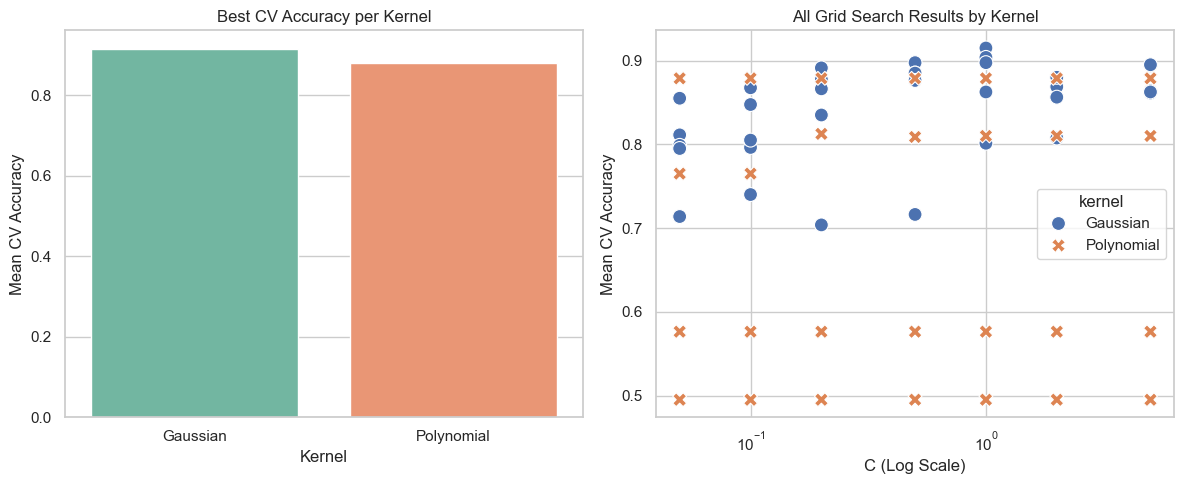

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results_df = pd.DataFrame(all_results)

sns.set(style="whitegrid")
plt.figure(figsize=(12, 5))

# 1. General comparson of best scores per kernel
plt.subplot(1, 2, 1)
best_scores = results_df.groupby("kernel")["mean_score"].max().reset_index()
sns.barplot(data=best_scores, x="kernel", y="mean_score", palette="Set2")
plt.title("Best CV Accuracy per Kernel")
plt.ylabel("Mean CV Accuracy")
plt.xlabel("Kernel")

# 2. Line plot for all results
plt.subplot(1, 2, 2)
sns.scatterplot(data=results_df, x="C", y="mean_score", hue="kernel", style="kernel", s=100)
plt.title("All Grid Search Results by Kernel")
plt.ylabel("Mean CV Accuracy")
plt.xlabel("C (Log Scale)")
plt.xscale("log")

plt.tight_layout()
plt.show()


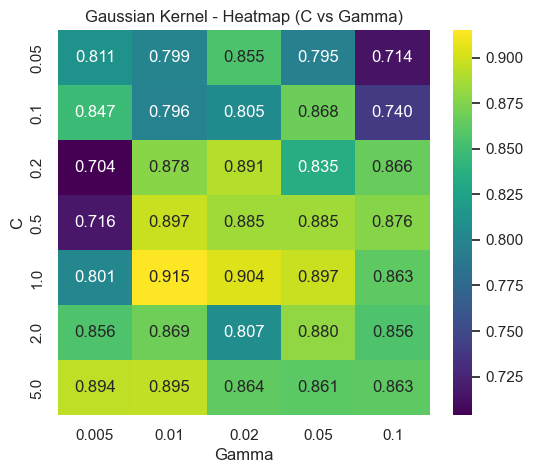

In [91]:
gaussian_df = results_df[results_df['kernel'] == 'Gaussian']
if not gaussian_df.empty:
    pivot_table = gaussian_df.pivot(index='C', columns='gamma', values='mean_score')
    plt.figure(figsize=(6, 5))
    sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
    plt.title("Gaussian Kernel - Heatmap (C vs Gamma)")
    plt.xlabel("Gamma")
    plt.ylabel("C")
    plt.show()


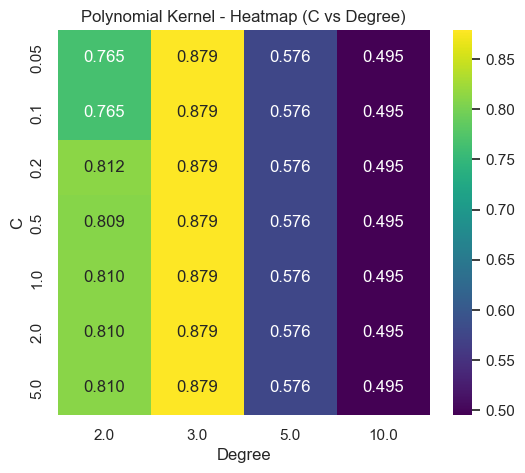

In [92]:
poly_df = results_df[results_df['kernel'] == 'Polynomial']
if not poly_df.empty:
    pivot_table = poly_df.pivot(index='C', columns='degree', values='mean_score')
    plt.figure(figsize=(6, 5))
    sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
    plt.title("Polynomial Kernel - Heatmap (C vs Degree)")
    plt.xlabel("Degree")
    plt.ylabel("C")
    plt.show()

In [93]:
poly_df['C'] = poly_df['C'].astype(str)
gaussian_df['C'] = gaussian_df['C'].astype(str)

C:\Users\User\AppData\Local\Temp\ipykernel_17972\3821612633.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  poly_df['C'] = poly_df['C'].astype(str)
C:\Users\User\AppData\Local\Temp\ipykernel_17972\3821612633.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gaussian_df['C'] = gaussian_df['C'].astype(str)


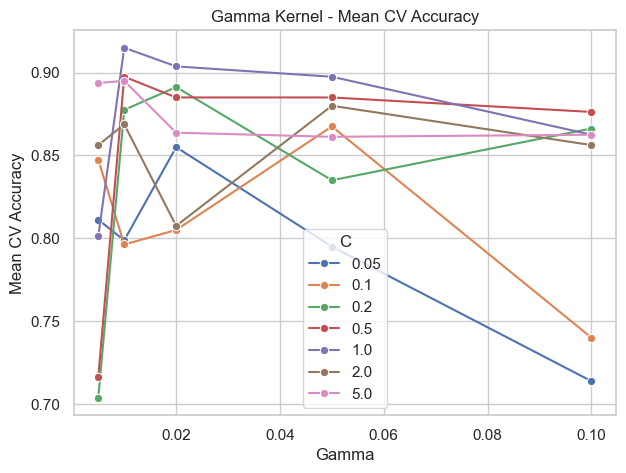

In [94]:
if not gaussian_df.empty:
    plt.figure(figsize=(7, 5))
    sns.lineplot(data=gaussian_df, x='gamma', y='mean_score', hue='C', marker='o')
    plt.title("Gamma Kernel - Mean CV Accuracy")
    plt.xlabel("Gamma")
    plt.ylabel("Mean CV Accuracy")
    plt.legend(title="C")
    plt.show()

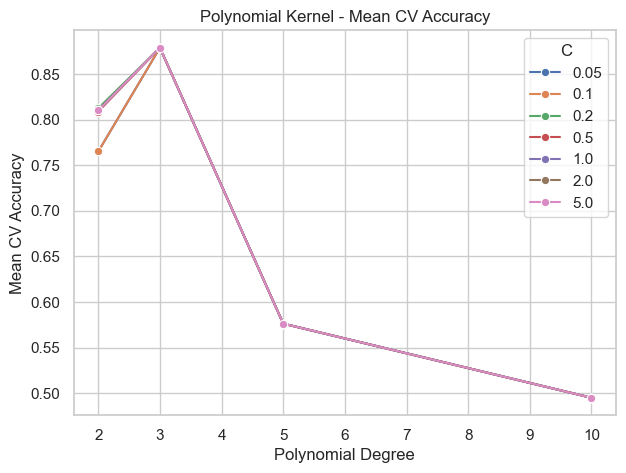

In [95]:
if not poly_df.empty:
    plt.figure(figsize=(7, 5))
    sns.lineplot(data=poly_df, x='degree', y='mean_score', hue='C', marker='o')
    plt.title("Polynomial Kernel - Mean CV Accuracy")
    plt.xlabel("Polynomial Degree")
    plt.ylabel("Mean CV Accuracy")
    plt.legend(title="C")
    plt.show()


# Bonus Part - Ethnicity Classification

In [25]:
df_2 = pd.read_csv("dataset/ETHNICITY_CLASSIFICATION.csv")

In [26]:
df_2.head()

,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,...,feat_24,feat_25,feat_26,feat_27,feat_28,feat_29,feat_30,feat_31,feat_32,gt
0,0.502792,-0.349373,-0.068018,-0.627533,0.130331,0.373488,-0.491088,0.416753,-0.046255,0.325566,...,0.374539,-0.605601,0.579226,-0.119241,0.185425,-0.255194,0.705415,-0.027761,0.581276,0
1,0.741646,-0.240194,-0.006548,-0.639129,-0.059524,0.457087,-0.500733,0.345128,-0.040395,0.334946,...,0.353851,-0.651629,0.129014,-0.034723,0.392575,-0.289928,0.380891,-0.157109,0.742231,0
2,2.836617,1.256781,2.227900,-0.603728,0.200403,1.366685,-0.666864,1.156750,-0.004516,0.767839,...,0.265453,-0.762246,-0.331476,0.051758,1.255034,-0.529064,1.412283,1.182029,3.046791,0
3,2.576996,1.784919,3.166102,-0.539903,0.108954,1.773622,-0.708488,2.679638,-0.313469,1.817676,...,0.295006,-0.866968,2.203584,-0.428082,-0.368396,-0.398743,4.043780,2.281445,5.065996,0
4,1.614504,1.103544,0.755605,-0.561434,-0.551708,0.936586,-0.575693,0.533321,0.033991,0.980126,...,0.155448,-0.825574,-0.627675,0.060466,0.815617,-0.434781,0.040881,-0.152861,2.191638,0


<Axes: xlabel='gt'>

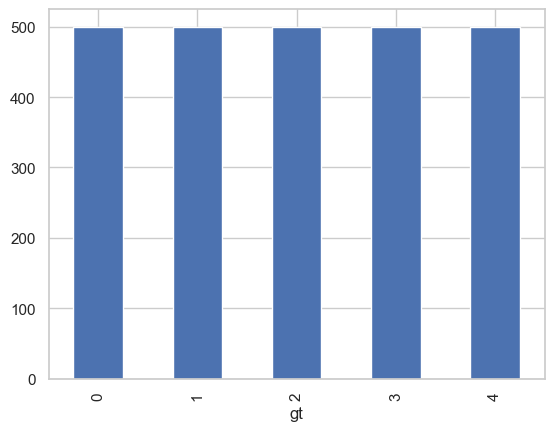

In [27]:
df_2['gt'].value_counts().plot(kind='bar') #balanced classes

In [28]:
from itertools import combinations

unique_values = df_2['gt'].unique()
possible_combinations = list(combinations(unique_values, 3))

for combo in possible_combinations:
    print(combo)

(0, 1, 2)
(0, 1, 3)
(0, 1, 4)
(0, 2, 3)
(0, 2, 4)
(0, 3, 4)
(1, 2, 3)
(1, 2, 4)
(1, 3, 4)
(2, 3, 4)


In [49]:
from itertools import combinations  


class MultiSVM(SVM):
    def __init__(self, method="OvR", *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.method = method
        self.models = {}  # dict per OvR, sarà sovrascritto se OvO
        self.pair_classes = []  # usata solo in OvO
        self.classes = None
        self.binary_model = None

    def fit(self, X, y):
        classes = np.unique(y)
        if self.method not in ["OvO", "OvR"]:
            raise ValueError('Please select "OvO" or "OvR"')

        if len(classes) < 2:
            raise ValueError("Please select 2 or more classes")

        self.classes = np.array(classes)

        if len(classes) == 2:
            self.binary_model = SVM(C=self.C, kernel=self.kernel_type, gamma=self.gamma, p=self.p, tol=self.tol)
            self.binary_model.fit(X, y)
        elif len(classes) >= 3 and self.method == "OvR":
            self.models = {}  # dict
            for cls in classes:
                y_bin = np.where(y == cls, 1, -1)
                model = SVM(C=self.C, kernel=self.kernel_type, gamma=self.gamma, p=self.p, tol=self.tol)
                model.fit(X, y_bin)
                self.models[cls] = model
        elif len(classes) >= 3 and self.method == "OvO":
            self.models = []  # lista per modelli
            self.pair_classes = []
            for cls1, cls2 in combinations(self.classes, 2):
                idx = np.where((y == cls1) | (y == cls2))[0]
                X_pair = X[idx]
                y_pair = y[idx]
                y_bin = np.where(y_pair == cls1, 1, -1)
                model = SVM(C=self.C, kernel=self.kernel_type, gamma=self.gamma, p=self.p, tol=self.tol)
                model.fit(X_pair, y_bin)
                self.models.append(model)
                self.pair_classes.append((cls1, cls2))
        return self

    def fit_smo(self, X, y):
        classes = np.unique(y)
        if self.method not in ["OvO", "OvR"]:
            raise ValueError('Please select "OvO" or "OvR"')

        if len(classes) < 2:
            raise ValueError("Please select 2 or more classes")

        self.classes = np.array(classes)

        if len(classes) == 2:
            self.binary_model = SVM(C=self.C, kernel=self.kernel_type, gamma=self.gamma, p=self.p, tol=self.tol)
            self.binary_model.fit_smo(X, y)
        elif len(classes) >= 3 and self.method == "OvR":
            self.models = {}
            for cls in classes:
                y_bin = np.where(y == cls, 1, -1)
                model = SVM(C=self.C, kernel=self.kernel_type, gamma=self.gamma, p=self.p, tol=self.tol)
                model.fit_smo(X, y_bin)
                self.models[cls] = model
        elif len(classes) >= 3 and self.method == "OvO":
            self.models = []
            self.pair_classes = []
            for cls1, cls2 in combinations(self.classes, 2):
                idx = np.where((y == cls1) | (y == cls2))[0]
                X_pair = X[idx]
                y_pair = y[idx]
                y_bin = np.where(y_pair == cls1, 1, -1)
                model = SVM(C=self.C, kernel=self.kernel_type, gamma=self.gamma, p=self.p, tol=self.tol)
                model.fit_smo(X_pair, y_bin)
                self.models.append(model)
                self.pair_classes.append((cls1, cls2))
        return self

    def predict(self, X):
        if len(self.classes) == 2:
            return self.binary_model.predict(X)
        elif len(self.classes) >= 3 and self.method == "OvR":
            scores = np.column_stack([self.models[cls].decision_function(X) for cls in self.classes])
            idx = np.argmax(scores, axis=1)
            return self.classes[idx]
        elif len(self.classes) >= 3 and self.method == "OvO":
            votes = np.zeros((X.shape[0], len(self.classes)), dtype=int)
            for model, (cls1, cls2) in zip(self.models, self.pair_classes):
                pred = model.predict(X)
                for i, p in enumerate(pred):
                    if p == 1:
                        votes[i, np.where(self.classes == cls1)[0][0]] += 1
                    else:
                        votes[i, np.where(self.classes == cls2)[0][0]] += 1
            return self.classes[np.argmax(votes, axis=1)]


In [ ]:
from itertools import combinations

results_ovr_classic_fit = []

for comb in possible_combinations:
    print(f"Training on classes: {comb}")
    selected_classes = comb  
    df_temp = df_2[df_2['gt'].isin(selected_classes)]

    X = df_temp.drop('gt', axis=1).values
    y = df_temp['gt'].values

    # 3. Split and fit
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    multi_svm = MultiSVM(C=1.0, kernel='Gaussian', gamma=0.5 , method='OvR')
    multi_svm.fit(X_train, y_train)
    y_pred = multi_svm.predict(X_test)

    # Store results
    results_ovr_classic_fit.append({
    'classes': comb,
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'y_pred': y_pred,
    'report': classification_report(y_test, y_pred, output_dict=True)  
    })


    # 4. Evaluation
    from sklearn.metrics import classification_report
    print(classification_report(y_test, y_pred))

Training on classes: (0, 1, 2)
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       104
           1       0.88      0.90      0.89        86
           2       0.90      0.89      0.89       110

    accuracy                           0.88       300
   macro avg       0.88      0.88      0.88       300
weighted avg       0.88      0.88      0.88       300

Training on classes: (0, 1, 3)
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       104
           1       0.81      0.85      0.83        86
           3       0.86      0.81      0.84       110

    accuracy                           0.84       300
   macro avg       0.84      0.84      0.84       300
weighted avg       0.84      0.84      0.84       300

Training on classes: (0, 1, 4)
              precision    recall  f1-score   support

           0       0.80      0.77      0.78       104
           1       0.80      0.84   

In [31]:
for i in range(len(results_ovr_classic_fit)):
    res = results_ovr_classic_fit[i]
    print("Classi:", res['classes'])
    print("Accuracy:", res['report']['accuracy'])

Classi: (0, 1, 2)
Accuracy: 0.8766666666666667
Classi: (0, 1, 3)
Accuracy: 0.8366666666666667
Classi: (0, 1, 4)
Accuracy: 0.78
Classi: (0, 2, 3)
Accuracy: 0.8633333333333333
Classi: (0, 2, 4)
Accuracy: 0.8
Classi: (0, 3, 4)
Accuracy: 0.7266666666666667
Classi: (1, 2, 3)
Accuracy: 0.89
Classi: (1, 2, 4)
Accuracy: 0.8766666666666667
Classi: (1, 3, 4)
Accuracy: 0.7966666666666666
Classi: (2, 3, 4)
Accuracy: 0.7633333333333333


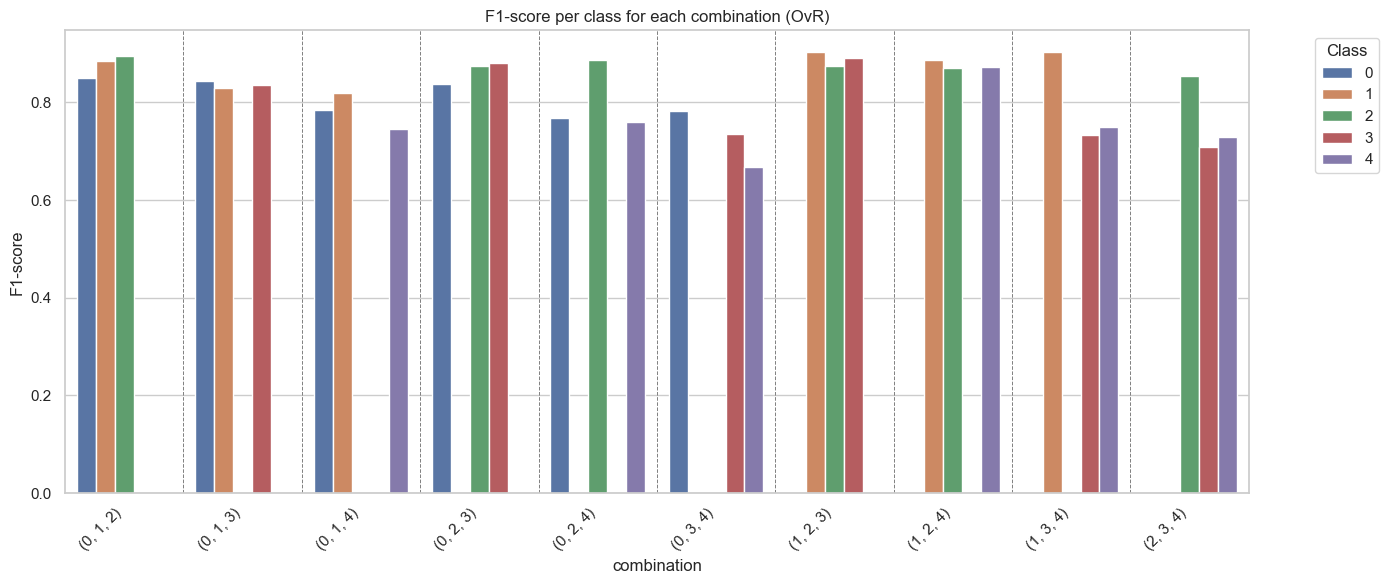

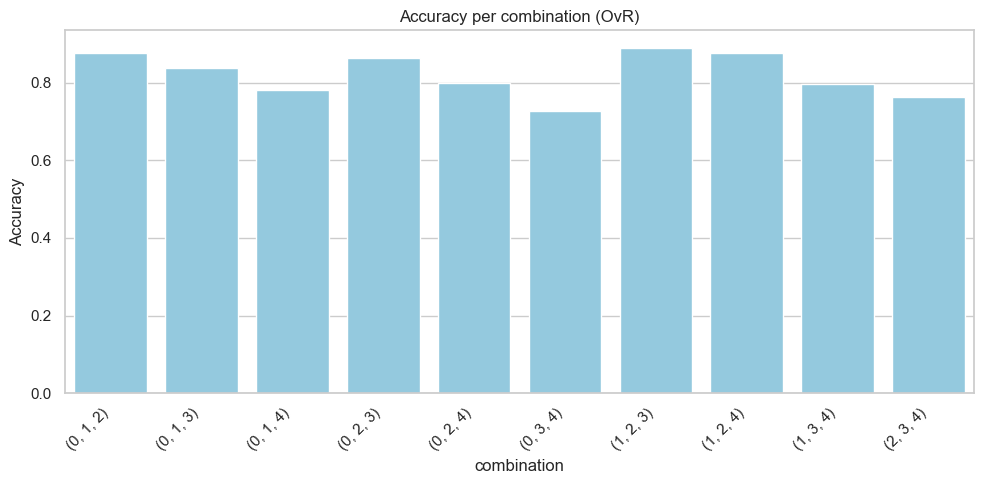

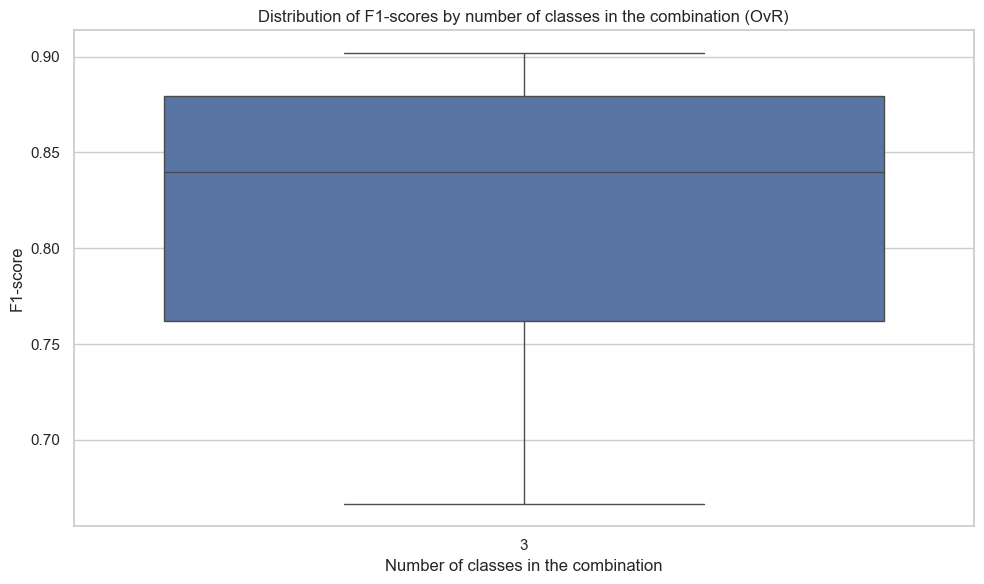

=== OvR PERFORMANCE SUMMARY ===

1. Average performance by number of classes:
               mean       std  count
n_classes                           
3          0.821676  0.067809     30

2. Best combinations by F1-score:
combination  f1-score
  (1, 2, 3)  0.890000
  (0, 1, 2)  0.876667
  (1, 2, 4)  0.876667
  (0, 2, 3)  0.863333
  (0, 1, 3)  0.836667

3. Worst combinations by F1-score:
combination  f1-score
  (0, 3, 4)  0.726667
  (2, 3, 4)  0.763333
  (0, 1, 4)  0.780000
  (1, 3, 4)  0.796667
  (0, 2, 4)  0.800000


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plot_data = []

for result in results_ovr_classic_fit:
    comb = result['classes']
    report = result['report']
    
    for class_label, metrics in report.items():
        if class_label in ['accuracy', 'macro avg', 'weighted avg']:
            continue
        plot_data.append({
            'class': class_label,
            'f1-score': metrics['f1-score'],
            'precision': metrics['precision'],
            'recall': metrics['recall'],
            'combination': str(comb),
            'n_classes': len(comb)  
        })
    
    # Add overall accuracy as a separate entry
    plot_data.append({
        'class': 'overall',
        'f1-score': report['accuracy'],
        'precision': None,
        'recall': None,
        'combination': str(comb),
        'n_classes': len(comb)  
    })

# Create a DataFrame for plotting
df_plot = pd.DataFrame(plot_data)

# ----------- F1-SCORE PER CLASS -----------

plt.figure(figsize=(14, 6))

# Filter out the overall accuracy rows
df_classes = df_plot[df_plot['class'] != 'overall']

ax = sns.barplot(
    data=df_classes,
    x='combination', y='f1-score', hue='class'
)
plt.title("F1-score per class for each combination (OvR)")
plt.ylabel("F1-score")
plt.xticks(rotation=45, ha='right')  
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')

# ➖ Dividing lines between combinations
combinations = df_classes['combination'].unique()
n_combinations = len(combinations)

for i in range(n_combinations - 1):
    plt.axvline(x=i + 0.5, color='gray', linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.show()

# ----------- ACCURACY PER COMBINATION -----------

plt.figure(figsize=(10, 5))
sns.barplot(data=df_plot[df_plot['class'] == 'overall'],
           x='combination', y='f1-score', color='skyblue')
plt.title("Accuracy per combination (OvR)")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha='right')  
plt.tight_layout()
plt.show()

# ----------- DISTRIBUTION OF PERFORMANCE BY NUMBER OF CLASSES -----------

plt.figure(figsize=(10, 6))

# Boxplot of F1-scores grouped by number of classes in the combination
sns.boxplot(
    data=df_classes,
    x='n_classes', y='f1-score'
)
plt.title("Distribution of F1-scores by number of classes in the combination (OvR)")
plt.xlabel("Number of classes in the combination")
plt.ylabel("F1-score")
plt.tight_layout()
plt.show()

# ----------- STATISTICAL SUMMARY -----------

print("=== OvR PERFORMANCE SUMMARY ===")
print("\n1. Average performance by number of classes:")
performance_by_n_classes = df_classes.groupby('n_classes')['f1-score'].agg(['mean', 'std', 'count'])
print(performance_by_n_classes)

print("\n2. Best combinations by F1-score:")
best_combinations = df_plot[df_plot['class'] == 'overall'].nlargest(5, 'f1-score')[['combination', 'f1-score']]
print(best_combinations.to_string(index=False))

print("\n3. Worst combinations by F1-score:")
worst_combinations = df_plot[df_plot['class'] == 'overall'].nsmallest(5, 'f1-score')[['combination', 'f1-score']]
print(worst_combinations.to_string(index=False))


In [ ]:
from itertools import combinations

results_ovr_smo_fit = []

for comb in possible_combinations:
    print(f"Training on classes: {comb}")
    selected_classes = comb  
    df_temp = df_2[df_2['gt'].isin(selected_classes)]

    X = df_temp.drop('gt', axis=1).values
    y = df_temp['gt'].values

    # 3. Split and fit
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    multi_svm = MultiSVM(C=1.0, kernel='Gaussian', gamma=0.5 , method='OvR')
    multi_svm.fit_smo(X_train, y_train)
    y_pred = multi_svm.predict(X_test)

    # Store results
    results_ovr_smo_fit.append({
    'classes': comb,
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'y_pred': y_pred,
    'report': classification_report(y_test, y_pred, output_dict=True)  
    })


    # 4. Evaluation
    from sklearn.metrics import classification_report
    print(classification_report(y_test, y_pred))

Training on classes: (0, 1, 2)

--- Iteration 1, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 191

--- Iteration 2, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 65

--- Iteration 3, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 76

--- Iteration 4, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 70

--- Iteration 5, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 69

--- Iteration 6, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 70

--- Iteration 7, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 54

--- Iteration 8, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 48

--- Iteration 9, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 45

--- 

In [34]:
for i in range(len(results_ovr_smo_fit)):
    res = results_ovr_smo_fit[i]
    print("Classi:", res['classes'])
    print("Accuracy:", res['report']['accuracy'])

Classi: (0, 1, 2)
Accuracy: 0.7833333333333333
Classi: (0, 1, 3)
Accuracy: 0.77
Classi: (0, 1, 4)
Accuracy: 0.7766666666666666
Classi: (0, 2, 3)
Accuracy: 0.7566666666666667
Classi: (0, 2, 4)
Accuracy: 0.6133333333333333
Classi: (0, 3, 4)
Accuracy: 0.5833333333333334
Classi: (1, 2, 3)
Accuracy: 0.7833333333333333
Classi: (1, 2, 4)
Accuracy: 0.7533333333333333
Classi: (1, 3, 4)
Accuracy: 0.7466666666666667
Classi: (2, 3, 4)
Accuracy: 0.7566666666666667


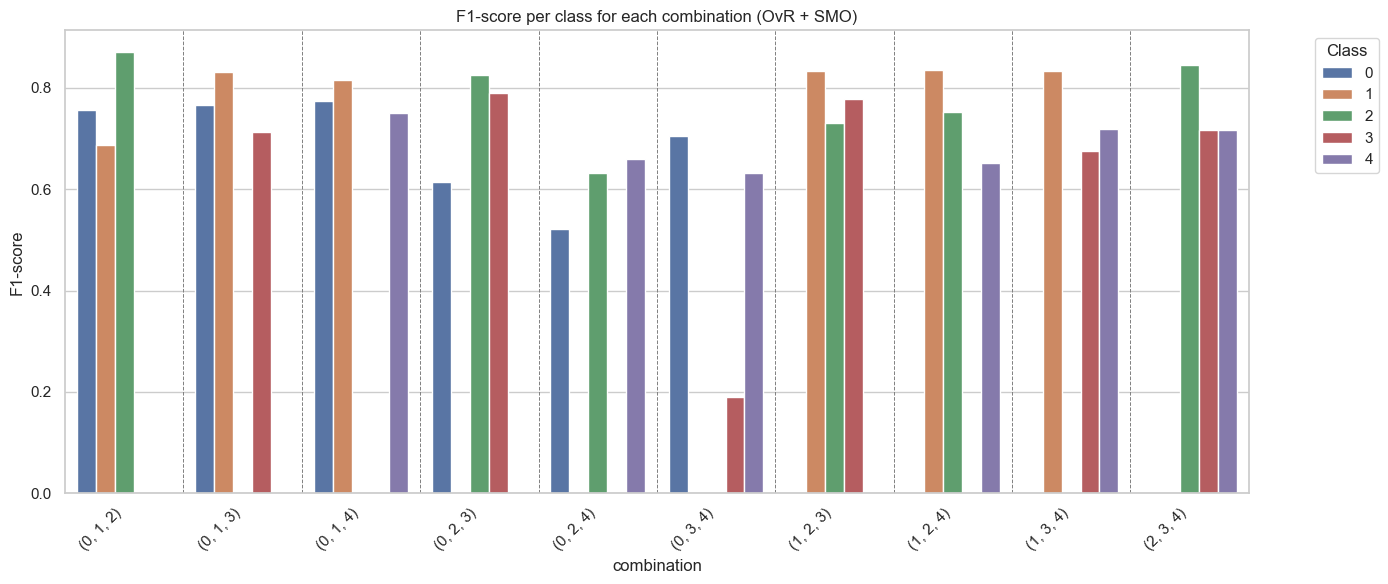

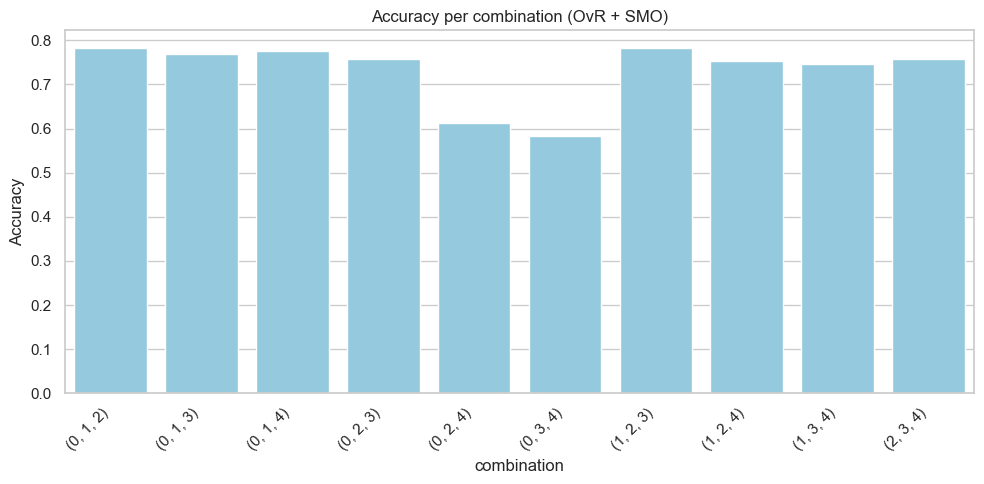

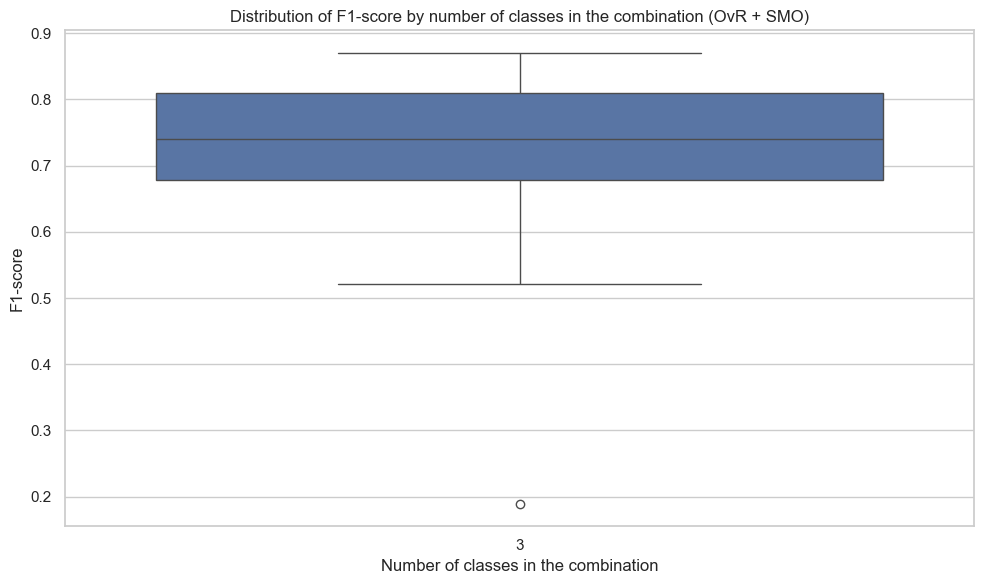

=== OvR + SMO PERFORMANCE SUMMARY ===

1. Average performance by number of classes:
               mean       std  count
n_classes                           
3          0.720468  0.129444     30

2. Best combinations by F1-score:
combination  f1-score
  (0, 1, 2)  0.783333
  (1, 2, 3)  0.783333
  (0, 1, 4)  0.776667
  (0, 1, 3)  0.770000
  (0, 2, 3)  0.756667

3. Worst combinations by F1-score:
combination  f1-score
  (0, 3, 4)  0.583333
  (0, 2, 4)  0.613333
  (1, 3, 4)  0.746667
  (1, 2, 4)  0.753333
  (0, 2, 3)  0.756667


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plot_data = []

for result in results_ovr_smo_fit:
    comb = result['classes']
    report = result['report']
    
    for class_label, metrics in report.items():
        if class_label in ['accuracy', 'macro avg', 'weighted avg']:
            continue
        plot_data.append({
            'class': class_label,
            'f1-score': metrics['f1-score'],
            'precision': metrics['precision'],
            'recall': metrics['recall'],
            'combination': str(comb),
            'n_classes': len(comb)  
        })
    
    # Add overall accuracy
    plot_data.append({
        'class': 'overall',
        'f1-score': report['accuracy'],
        'precision': None,
        'recall': None,
        'combination': str(comb),
        'n_classes': len(comb)  
    })

# Create a DataFrame for plotting
df_plot = pd.DataFrame(plot_data)

# ----------- F1-SCORE PER CLASS PLOT -----------

plt.figure(figsize=(14, 6))

# Filter the data to exclude 'overall'
df_classes = df_plot[df_plot['class'] != 'overall']

ax = sns.barplot(
    data=df_classes,
    x='combination', y='f1-score', hue='class'
)
plt.title("F1-score per class for each combination (OvR + SMO)")
plt.ylabel("F1-score")
plt.xticks(rotation=45, ha='right')  
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')

# Divider lines between combinations
combinations = df_classes['combination'].unique()
n_combinations = len(combinations)

for i in range(n_combinations - 1):
    plt.axvline(x=i + 0.5, color='gray', linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.show()

# ----------- ACCURACY PER COMBINATION PLOT -----------

plt.figure(figsize=(10, 5))
sns.barplot(data=df_plot[df_plot['class'] == 'overall'],
           x='combination', y='f1-score', color='skyblue')
plt.title("Accuracy per combination (OvR + SMO)")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha='right')  
plt.tight_layout()
plt.show()

# ----------- DISTRIBUTION OF PERFORMANCE BY NUMBER OF CLASSES -----------

plt.figure(figsize=(10, 6))

# Boxplot of performances grouped by number of classes
sns.boxplot(
    data=df_classes,
    x='n_classes', y='f1-score'
)
plt.title("Distribution of F1-score by number of classes in the combination (OvR + SMO)")  
plt.xlabel("Number of classes in the combination")
plt.ylabel("F1-score")
plt.tight_layout()
plt.show()

# ----------- STATISTICAL SUMMARY -----------

print("=== OvR + SMO PERFORMANCE SUMMARY ===")  
print("\n1. Average performance by number of classes:")
performance_by_n_classes = df_classes.groupby('n_classes')['f1-score'].agg(['mean', 'std', 'count'])
print(performance_by_n_classes)

print("\n2. Best combinations by F1-score:")
best_combinations = df_plot[df_plot['class'] == 'overall'].nlargest(5, 'f1-score')[['combination', 'f1-score']]
print(best_combinations.to_string(index=False))

print("\n3. Worst combinations by F1-score:")
worst_combinations = df_plot[df_plot['class'] == 'overall'].nsmallest(5, 'f1-score')[['combination', 'f1-score']]
print(worst_combinations.to_string(index=False))


In [ ]:
from itertools import combinations

results_ovo_classic_fit = []

for comb in possible_combinations:
    print(f"Training on classes: {comb}")
    selected_classes = comb  
    df_temp = df_2[df_2['gt'].isin(selected_classes)]

    X = df_temp.drop('gt', axis=1).values
    y = df_temp['gt'].values

    # 3. Split and fit
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    multi_svm = MultiSVM(C=1.0, kernel='Gaussian', gamma=0.5 , method='OvO')
    multi_svm.fit(X_train, y_train)
    y_pred = multi_svm.predict(X_test)

    # Store results
    results_ovo_classic_fit.append({
    'classes': comb,
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'y_pred': y_pred,
    'report': classification_report(y_test, y_pred, output_dict=True)  
    })


    # 4. Evaluation
    from sklearn.metrics import classification_report
    print(classification_report(y_test, y_pred))

Training on classes: (0, 1, 2)
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       104
           1       0.86      0.83      0.84        86
           2       0.89      0.88      0.89       110

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300

Training on classes: (0, 1, 3)
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       104
           1       0.84      0.81      0.83        86
           3       0.85      0.85      0.85       110

    accuracy                           0.84       300
   macro avg       0.84      0.84      0.84       300
weighted avg       0.84      0.84      0.84       300

Training on classes: (0, 1, 4)
              precision    recall  f1-score   support

           0       0.78      0.73      0.76       104
           1       0.86      0.77   

In [39]:
for i in range(len(results_ovo_classic_fit)):
    res = results_ovo_classic_fit[i]
    print("Classi:", res['classes'])
    print("Accuracy:", res['report']['accuracy'])

Classi: (0, 1, 2)
Accuracy: 0.8533333333333334
Classi: (0, 1, 3)
Accuracy: 0.8433333333333334
Classi: (0, 1, 4)
Accuracy: 0.77
Classi: (0, 2, 3)
Accuracy: 0.8566666666666667
Classi: (0, 2, 4)
Accuracy: 0.8
Classi: (0, 3, 4)
Accuracy: 0.7166666666666667
Classi: (1, 2, 3)
Accuracy: 0.89
Classi: (1, 2, 4)
Accuracy: 0.8733333333333333
Classi: (1, 3, 4)
Accuracy: 0.7866666666666666
Classi: (2, 3, 4)
Accuracy: 0.7733333333333333


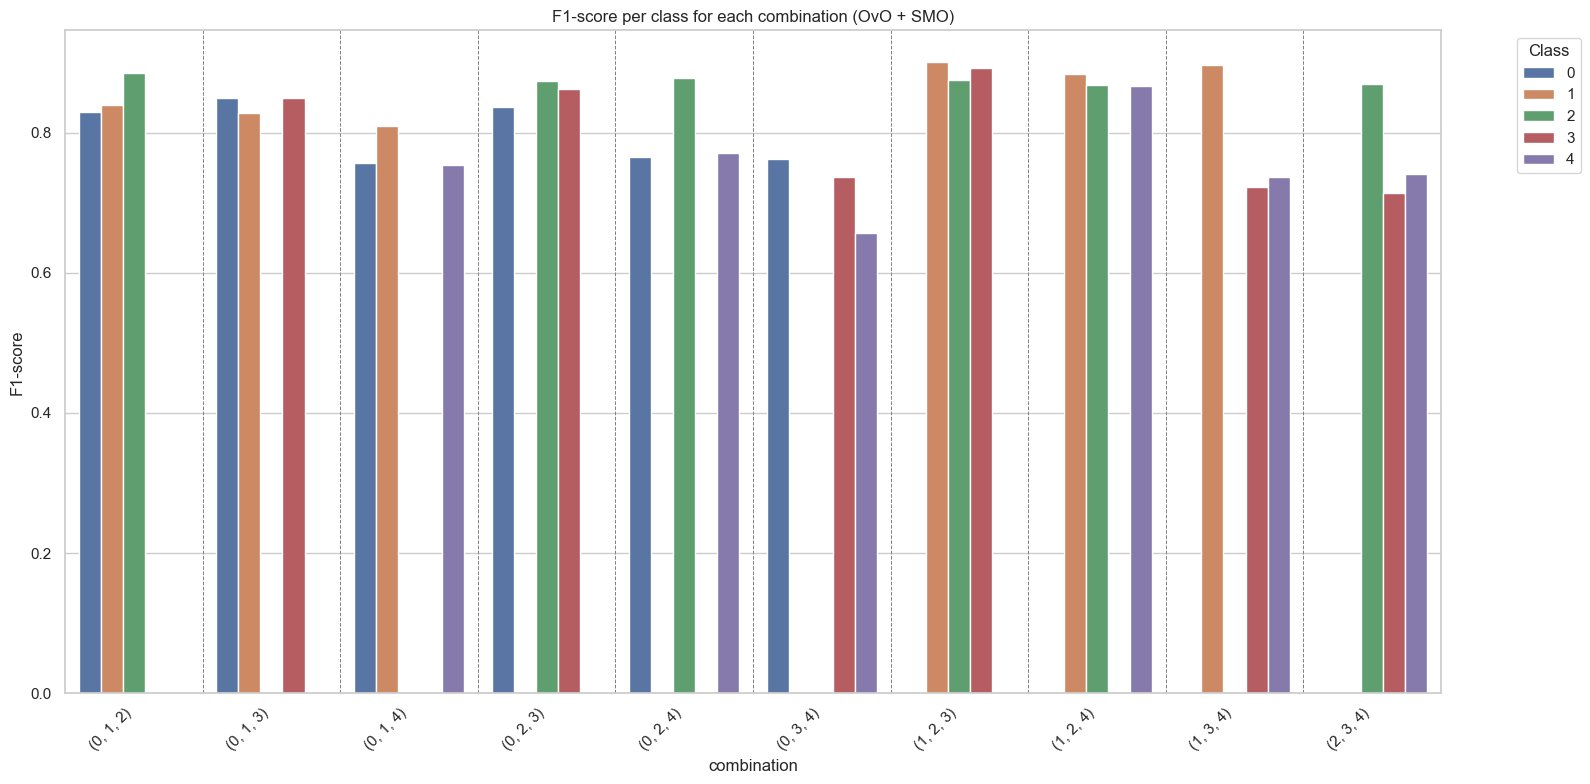

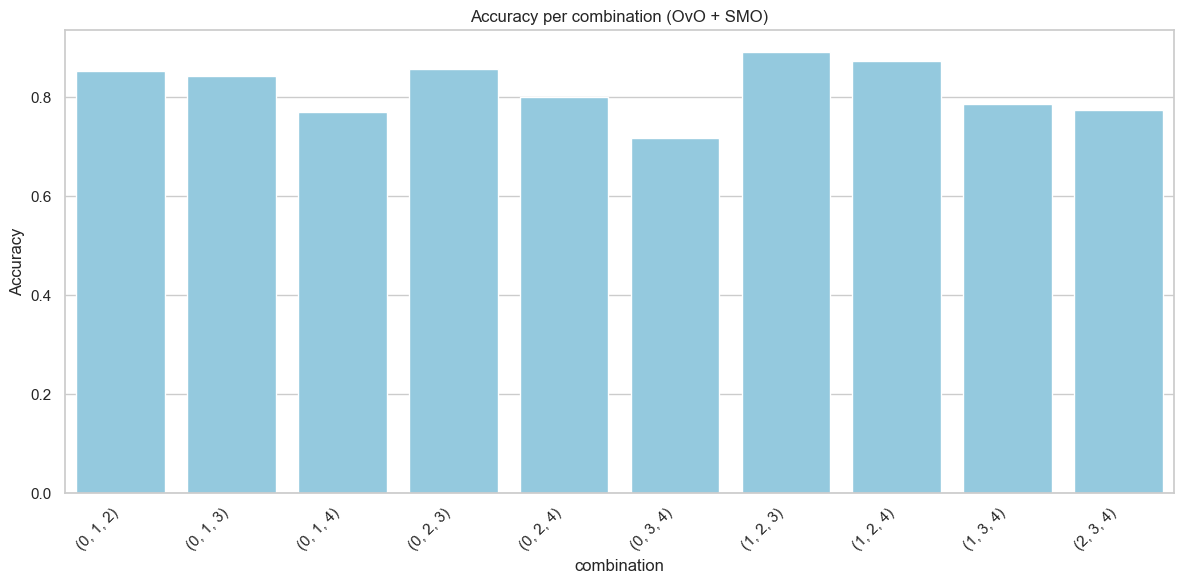

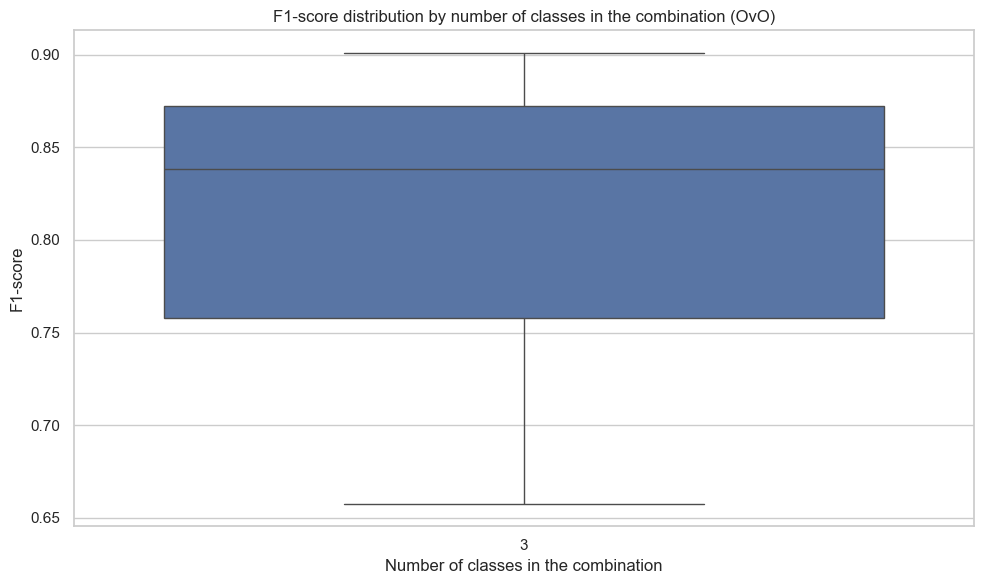

=== PERFORMANCE SUMMARY OvO ===

1. Average performance by number of classes:
               mean       std  count
n_classes                           
3          0.817184  0.067193     30

2. Best combinations by F1-score:
combination  f1-score
  (1, 2, 3)  0.890000
  (1, 2, 4)  0.873333
  (0, 2, 3)  0.856667
  (0, 1, 2)  0.853333
  (0, 1, 3)  0.843333

3. Worst combinations by F1-score:
combination  f1-score
  (0, 3, 4)  0.716667
  (0, 1, 4)  0.770000
  (2, 3, 4)  0.773333
  (1, 3, 4)  0.786667
  (0, 2, 4)  0.800000


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plot_data = []

for result in results_ovo_classic_fit:
    comb = result['classes']
    report = result['report']
    
    for class_label, metrics in report.items():
        if class_label in ['accuracy', 'macro avg', 'weighted avg']:
            continue
        plot_data.append({
            'class': class_label,
            'f1-score': metrics['f1-score'],
            'precision': metrics['precision'],
            'recall': metrics['recall'],
            'combination': str(comb),
            'n_classes': len(comb)  
        })
    
    # Add overall accuracy
    plot_data.append({
        'class': 'overall',
        'f1-score': report['accuracy'],
        'precision': None,
        'recall': None,
        'combination': str(comb),
        'n_classes': len(comb)
    })

# Create a DataFrame for plotting
df_plot = pd.DataFrame(plot_data)

# ----------- F1-SCORE PER CLASS PLOT WITH DIVIDER LINES -----------

plt.figure(figsize=(16, 8))

# Filter out 'overall'
df_classes = df_plot[df_plot['class'] != 'overall']

ax = sns.barplot(
    data=df_classes,
    x='combination', y='f1-score', hue='class'
)
plt.title("F1-score per class for each combination (OvO + SMO)")
plt.ylabel("F1-score")
plt.xticks(rotation=45, ha='right')  
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')

# Divider lines between combinations
combinations = df_classes['combination'].unique()
n_combinations = len(combinations)

for i in range(n_combinations - 1):
    plt.axvline(x=i + 0.5, color='gray', linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.show()

# ----------- ACCURACY PER COMBINATION PLOT -----------

plt.figure(figsize=(12, 6))
accuracy_data = df_plot[df_plot['class'] == 'overall']

ax = sns.barplot(
    data=accuracy_data,
    x='combination', y='f1-score', 
    color='skyblue'
)
plt.title("Accuracy per combination (OvO + SMO)")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# ----------- DISTRIBUTION OF PERFORMANCE BY NUMBER OF CLASSES -----------

plt.figure(figsize=(10, 6))

# Boxplot of performance grouped by number of classes
sns.boxplot(
    data=df_classes,
    x='n_classes', y='f1-score'
)
plt.title("F1-score distribution by number of classes in the combination (OvO)")
plt.xlabel("Number of classes in the combination")
plt.ylabel("F1-score")
plt.tight_layout()
plt.show()

# ----------- STATISTICAL SUMMARY -----------

print("=== PERFORMANCE SUMMARY OvO ===")
print("\n1. Average performance by number of classes:")
performance_by_n_classes = df_classes.groupby('n_classes')['f1-score'].agg(['mean', 'std', 'count'])
print(performance_by_n_classes)

print("\n2. Best combinations by F1-score:")
best_combinations = df_plot[df_plot['class'] == 'overall'].nlargest(5, 'f1-score')[['combination', 'f1-score']]
print(best_combinations.to_string(index=False))

print("\n3. Worst combinations by F1-score:")
worst_combinations = df_plot[df_plot['class'] == 'overall'].nsmallest(5, 'f1-score')[['combination', 'f1-score']]
print(worst_combinations.to_string(index=False))


In [43]:
from itertools import combinations

results_ovo_smo_fit = []

for comb in possible_combinations:
    print(f"Training on classes: {comb}")
    selected_classes = comb  
    df_temp = df_2[df_2['gt'].isin(selected_classes)]

    X = df_temp.drop('gt', axis=1).values
    y = df_temp['gt'].values

    # 3. Split and fit
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    multi_svm = MultiSVM(C=1.0, kernel='Gaussian', gamma=0.5 , method='OvO')
    multi_svm.fit_smo(X_train, y_train)
    y_pred = multi_svm.predict(X_test)

    # Store results
    results_ovo_smo_fit.append({
    'classes': comb,
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'y_pred': y_pred,
    'report': classification_report(y_test, y_pred, output_dict=True)  
    })


    # 4. Evaluation
    from sklearn.metrics import classification_report
    print(classification_report(y_test, y_pred))

Training on classes: (0, 1, 2)

--- Iteration 1, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 160

--- Iteration 2, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 215

--- Iteration 3, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 179

--- Iteration 4, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 222

--- Iteration 5, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 203

--- Iteration 6, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 203

--- Iteration 7, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 202

--- Iteration 8, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 187

--- Iteration 9, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 1

In [44]:
for i in range(len(results_ovo_smo_fit)):
    res = results_ovo_smo_fit[i]
    print("Classi:", res['classes'])
    print("Accuracy:", res['report']['accuracy'])

Classi: (0, 1, 2)
Accuracy: 0.76
Classi: (0, 1, 3)
Accuracy: 0.69
Classi: (0, 1, 4)
Accuracy: 0.5566666666666666
Classi: (0, 2, 3)
Accuracy: 0.53
Classi: (0, 2, 4)
Accuracy: 0.6133333333333333
Classi: (0, 3, 4)
Accuracy: 0.46
Classi: (1, 2, 3)
Accuracy: 0.6133333333333333
Classi: (1, 2, 4)
Accuracy: 0.7
Classi: (1, 3, 4)
Accuracy: 0.5733333333333334
Classi: (2, 3, 4)
Accuracy: 0.57


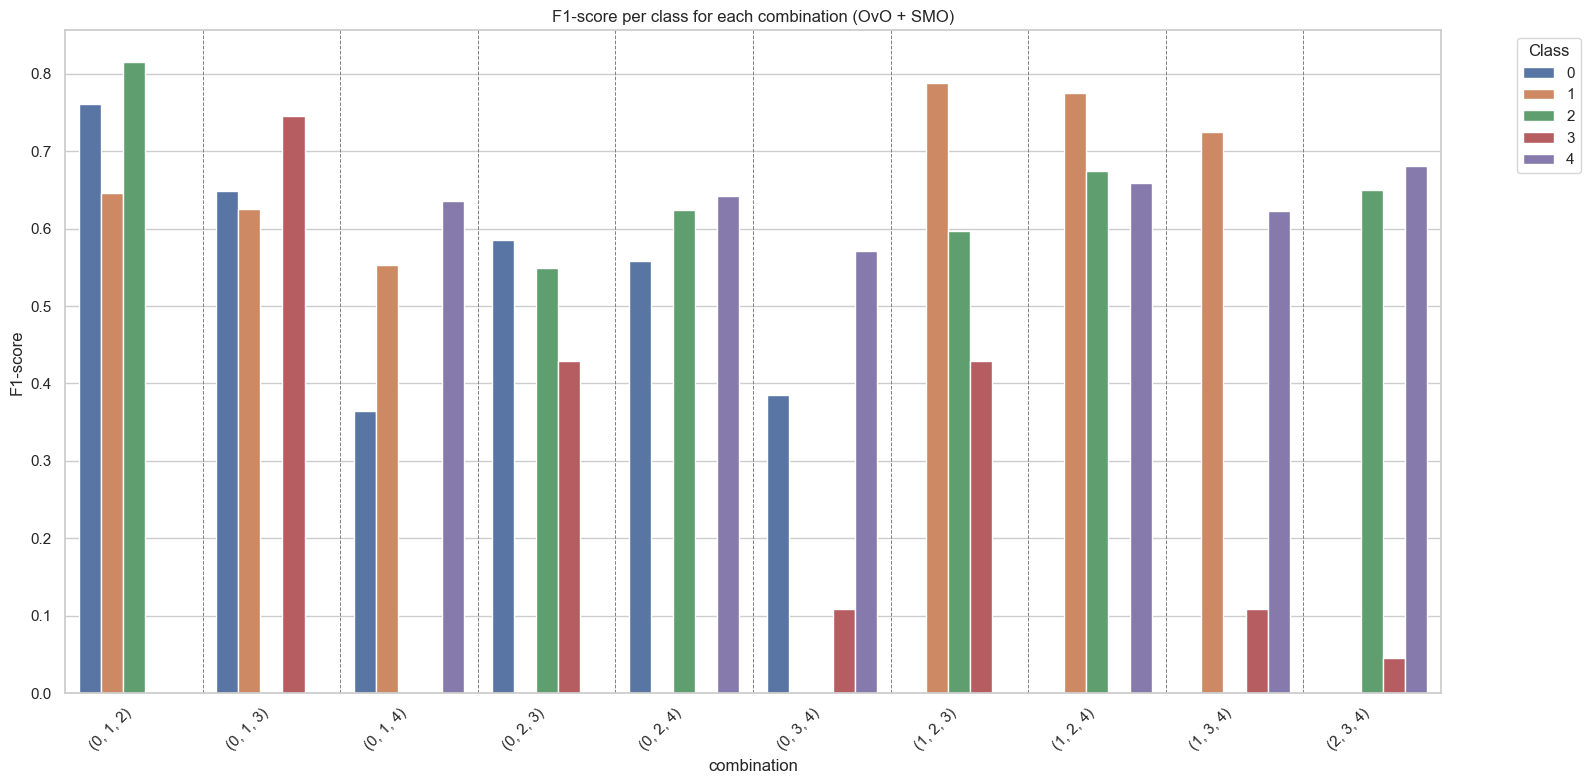

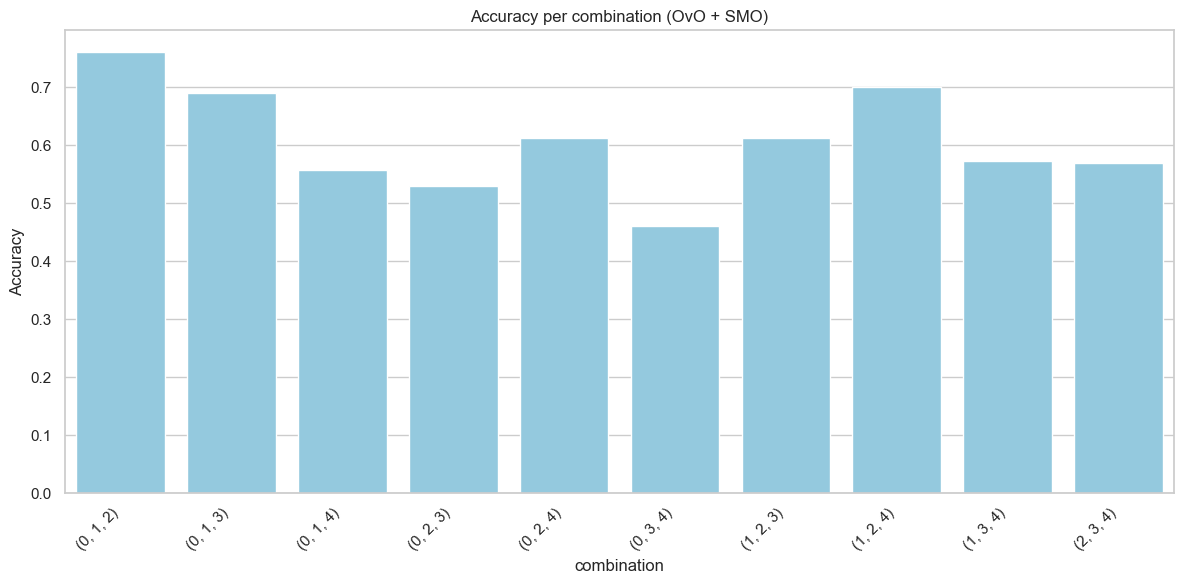

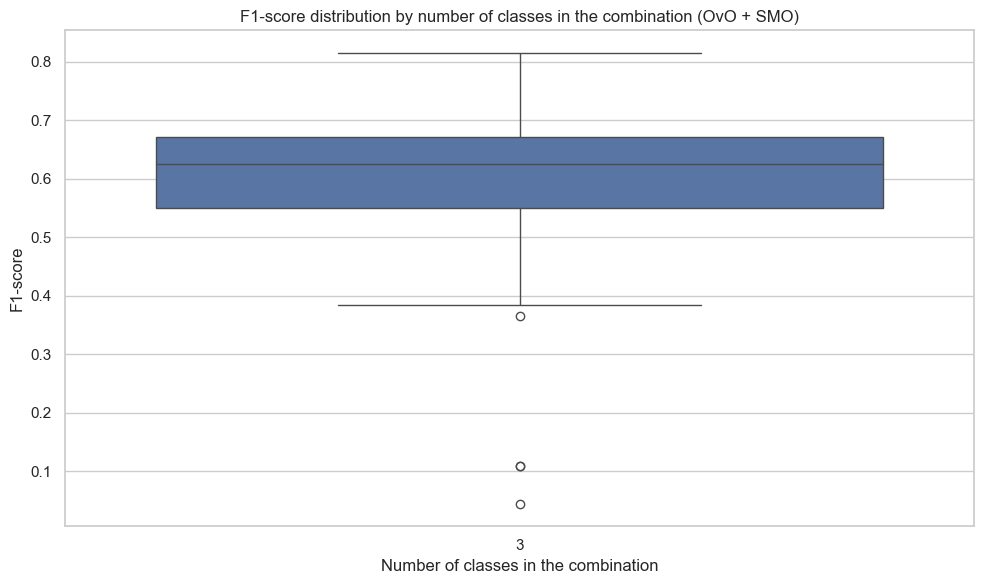

=== PERFORMANCE SUMMARY OvO + SMO ===

1. Average performance by number of classes:
              mean       std  count
n_classes                          
3          0.56666  0.197206     30

2. Best combinations by F1-score:
combination  f1-score
  (0, 1, 2)  0.760000
  (1, 2, 4)  0.700000
  (0, 1, 3)  0.690000
  (0, 2, 4)  0.613333
  (1, 2, 3)  0.613333

3. Worst combinations by F1-score:
combination  f1-score
  (0, 3, 4)  0.460000
  (0, 2, 3)  0.530000
  (0, 1, 4)  0.556667
  (2, 3, 4)  0.570000
  (1, 3, 4)  0.573333


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plot_data = []

for result in results_ovo_smo_fit:
    comb = result['classes']
    report = result['report']
    
    for class_label, metrics in report.items():
        if class_label in ['accuracy', 'macro avg', 'weighted avg']:
            continue
        plot_data.append({
            'class': class_label,
            'f1-score': metrics['f1-score'],
            'precision': metrics['precision'],
            'recall': metrics['recall'],
            'combination': str(comb),
            'n_classes': len(comb)  
        })
    
    # Add overall accuracy
    plot_data.append({
        'class': 'overall',
        'f1-score': report['accuracy'],
        'precision': None,
        'recall': None,
        'combination': str(comb),
        'n_classes': len(comb)
    })

# Create a DataFrame for plots
df_plot = pd.DataFrame(plot_data)

# ----------- F1-SCORE PER CLASS PLOT -----------

plt.figure(figsize=(16, 8))

# Filter data to exclude 'overall'
df_classes = df_plot[df_plot['class'] != 'overall']

ax = sns.barplot(
    data=df_classes,
    x='combination', y='f1-score', hue='class'
)
plt.title("F1-score per class for each combination (OvO + SMO)")
plt.ylabel("F1-score")
plt.xticks(rotation=45, ha='right')  
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')

# Divider lines between combinations
combinations = df_classes['combination'].unique()
n_combinations = len(combinations)

for i in range(n_combinations - 1):
    plt.axvline(x=i + 0.5, color='gray', linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.show()

# ----------- ACCURACY PER COMBINATION PLOT -----------

plt.figure(figsize=(12, 6))
accuracy_data = df_plot[df_plot['class'] == 'overall']

ax = sns.barplot(
    data=accuracy_data,
    x='combination', y='f1-score', 
    color='skyblue'
)
plt.title("Accuracy per combination (OvO + SMO)")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# ----------- DISTRIBUTION OF PERFORMANCE BY NUMBER OF CLASSES -----------

plt.figure(figsize=(10, 6))

# Boxplot of performance grouped by number of classes
sns.boxplot(
    data=df_classes,
    x='n_classes', y='f1-score'
)
plt.title("F1-score distribution by number of classes in the combination (OvO + SMO)")
plt.xlabel("Number of classes in the combination")
plt.ylabel("F1-score")
plt.tight_layout()
plt.show()

# ----------- STATISTICAL SUMMARY -----------

print("=== PERFORMANCE SUMMARY OvO + SMO ===")
print("\n1. Average performance by number of classes:")
performance_by_n_classes = df_classes.groupby('n_classes')['f1-score'].agg(['mean', 'std', 'count'])
print(performance_by_n_classes)

print("\n2. Best combinations by F1-score:")
best_combinations = df_plot[df_plot['class'] == 'overall'].nlargest(5, 'f1-score')[['combination', 'f1-score']]
print(best_combinations.to_string(index=False))

print("\n3. Worst combinations by F1-score:")
worst_combinations = df_plot[df_plot['class'] == 'overall'].nsmallest(5, 'f1-score')[['combination', 'f1-score']]
print(worst_combinations.to_string(index=False))


              precision    recall  f1-score   support

           0       0.73      0.72      0.73       100
           1       0.77      0.82      0.80        88
           2       0.90      0.84      0.87       108
           3       0.75      0.66      0.70       111
           4       0.51      0.61      0.56        93

    accuracy                           0.73       500
   macro avg       0.74      0.73      0.73       500
weighted avg       0.74      0.73      0.73       500

Confusion Matrix:
 [[72  6  4  4 14]
 [ 2 72  2  4  8]
 [ 4  2 91  4  7]
 [ 9  3  1 73 25]
 [11 10  3 12 57]]


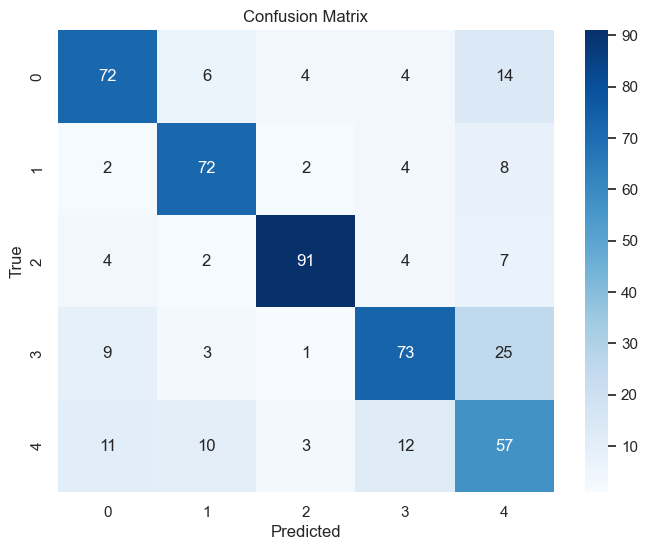

In [50]:
from itertools import combinations

X = df_2.drop('gt', axis=1).values
y = df_2['gt'].values

# 3. Split and fit
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

multi_svm = MultiSVM(C=1.0, kernel='Gaussian', gamma=0.5 , method='OvO')
multi_svm.fit(X_train, y_train)
y_pred = multi_svm.predict(X_test)

# 4. Evaluation
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

              precision    recall  f1-score   support

           0       0.73      0.74      0.74       100
           1       0.76      0.84      0.80        88
           2       0.87      0.86      0.87       108
           3       0.75      0.71      0.73       111
           4       0.59      0.57      0.58        93

    accuracy                           0.75       500
   macro avg       0.74      0.74      0.74       500
weighted avg       0.75      0.75      0.75       500

Confusion Matrix:
 [[74  6  5  5 10]
 [ 2 74  2  4  6]
 [ 4  2 93  5  4]
 [ 9  3  3 79 17]
 [12 12  4 12 53]]


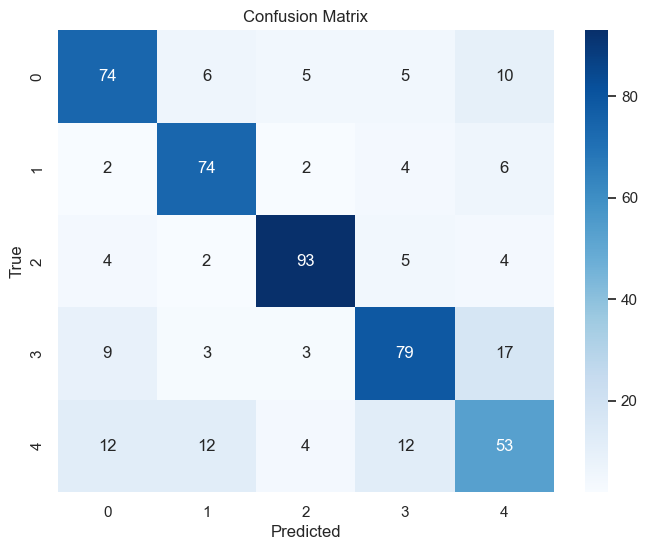

In [51]:
from itertools import combinations

X = df_2.drop('gt', axis=1).values
y = df_2['gt'].values

# 3. Split and fit
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

multi_svm = MultiSVM(C=1.0, kernel='Gaussian', gamma=0.5 , method='OvR')
multi_svm.fit(X_train, y_train)
y_pred = multi_svm.predict(X_test)

# 4. Evaluation
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


--- Iteration 1, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 144

--- Iteration 2, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 192

--- Iteration 3, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 119

--- Iteration 4, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 150

--- Iteration 5, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 131

--- Iteration 6, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 119

--- Iteration 7, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 121

--- Iteration 8, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 142

--- Iteration 9, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 134

--- Iteration 10, consecuti

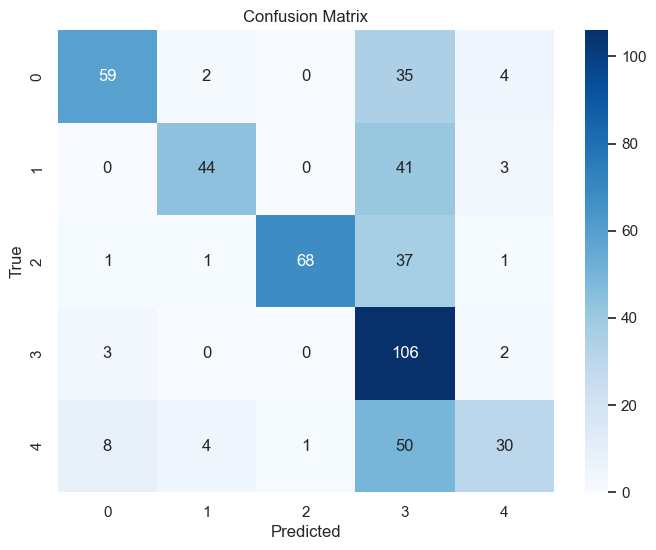

In [52]:
from itertools import combinations

X = df_2.drop('gt', axis=1).values
y = df_2['gt'].values

# 3. Split and fit
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

multi_svm = MultiSVM(C=1.0, kernel='Gaussian', gamma=0.5 , method='OvO')
multi_svm.fit_smo(X_train, y_train)
y_pred = multi_svm.predict(X_test)

# 4. Evaluation
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


--- Iteration 1, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 177

--- Iteration 2, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 74

--- Iteration 3, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 20

--- Iteration 4, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 18

--- Iteration 5, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 17

--- Iteration 6, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 35

--- Iteration 7, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 3

--- Iteration 8, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 0

--- Iteration 9, consecutive passes without updates: 1 ---
Number of alphas updated in this iteration: 0

--- Iteration 10, consecutive passes w

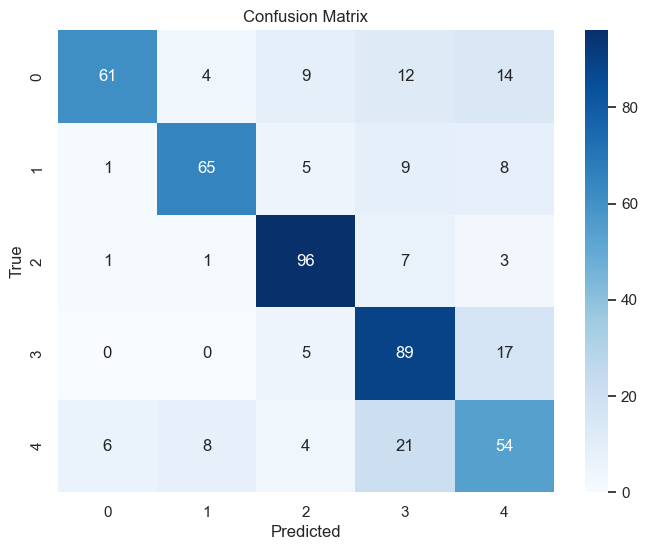

In [53]:
from itertools import combinations

X = df_2.drop('gt', axis=1).values
y = df_2['gt'].values

# 3. Split and fit
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

multi_svm = MultiSVM(C=1.0, kernel='Gaussian', gamma=0.5 , method='OvR')
multi_svm.fit_smo(X_train, y_train)
y_pred = multi_svm.predict(X_test)

# 4. Evaluation
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()